# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'CANONICAL' #, 'ORTHOGONAL', 'CANONICAL'
CUTOFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
criterion = 'test_score'  # test_score, train_score, err

# Helpeer Functions 

In [3]:
def get_plot_filename(plotname, minorcase):
    return 'graphs/{}_{}_{}_{}_{}_{}.pdf'.format(plotname, minorcase, CASE, MODEL, CUTOFF, criterion)

def get_table_filename(tablename, minorcase):
    return 'tables/{}_{}_{}_{}_{}_{}.csv'.format(tablename, minorcase, CASE, MODEL, CUTOFF, criterion)

def with_and_without_outliers(thisfeature: pd.core.series.Series, low = None, hig = None):
    spread = thisfeature.max() - thisfeature.min()
    if low == None:
        low = thisfeature.min()-spread*0.05
    if hig == None:
        hig = thisfeature.max()+spread*0.05
        
    fig, ax = plt.subplots(1,2,figsize=(30,10))
    h3=thisfeature.hist(bins=100, fill='k', ax=ax[1], density=True, label='data with outliers')
    h1=thisfeature[(thisfeature>low) & (thisfeature<hig)].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
    ax[0].legend()
    ax[0].set_xlabel('$E_f$ (eV)', x=1, labelpad=20)
    ax[0].set_ylabel('density counts', labelpad = 20)
    l = ax[1].legend()
    return fig


def compare_features(featureone, titleone, featuretwo, titletwo):
    fig, ax = plt.subplots(1,2,figsize=(30,10))
    h3=featureone.hist(bins=100, fill='k', ax=ax[1], density=True, label='total eneregy')
    h1=featuretwo.hist(bins=100, ax=ax[0],density=True,label='$\Delta E_f$')
    ax[1].set_xlabel(titleone, labelpad=20)
    ax[0].set_xlabel(titletwo, labelpad = 20)
    return fig
    #l = ax[1].legend()

def plot_pair(feature1, feature2, huefeature=None):
    if huefeature is None:
        huefeature = 'Class'
    fig, ax = plt.subplots()
    sns.scatterplot(data = data_w_classes, 
                    x=feature1,
                    y = feature2, ax = ax, hue=huefeature,
                    s=200)
    ax.set_xlabel(feature_titles[feature1])
    ax.set_ylabel(feature_titles[feature2])
    ax.legend(bbox_to_anchor=[1,1], markerscale=2)
    return fig

# Load Features

## Load briefsummary and its features

In [4]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [5]:
BOPCOEF_FILE = 'CRCOW_{}_NSC_{}_{}.pkl'.format(CASE,MODEL,CUTOFF)
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

## clean features: reduntandly convert all features to float and mean across sites

In [6]:
BopfoxFeatures.dropna(how='any',inplace=True)
M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
Mag = Features.MagFeature[BopfoxFeatures.index]
BOP_atom_average = pd.concat([M, S, AN, BN, Ainf, Binf, Mag], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)

## define the column names by type of feature

In [7]:
allcolumns = BOP.columns

In [8]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','') for s in allcolumns ]), index=allcolumns
)

In [9]:
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [10]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [11]:
useful_an = [f for f in real_feature if 'an' in f]
useful_bn = [f for f in real_feature if 'bn' in f]
useful_moment = [f for f in real_feature if 'moment' in f]
useful_sigmas = [f for f in real_feature if 'SIGMA' in f]

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [12]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

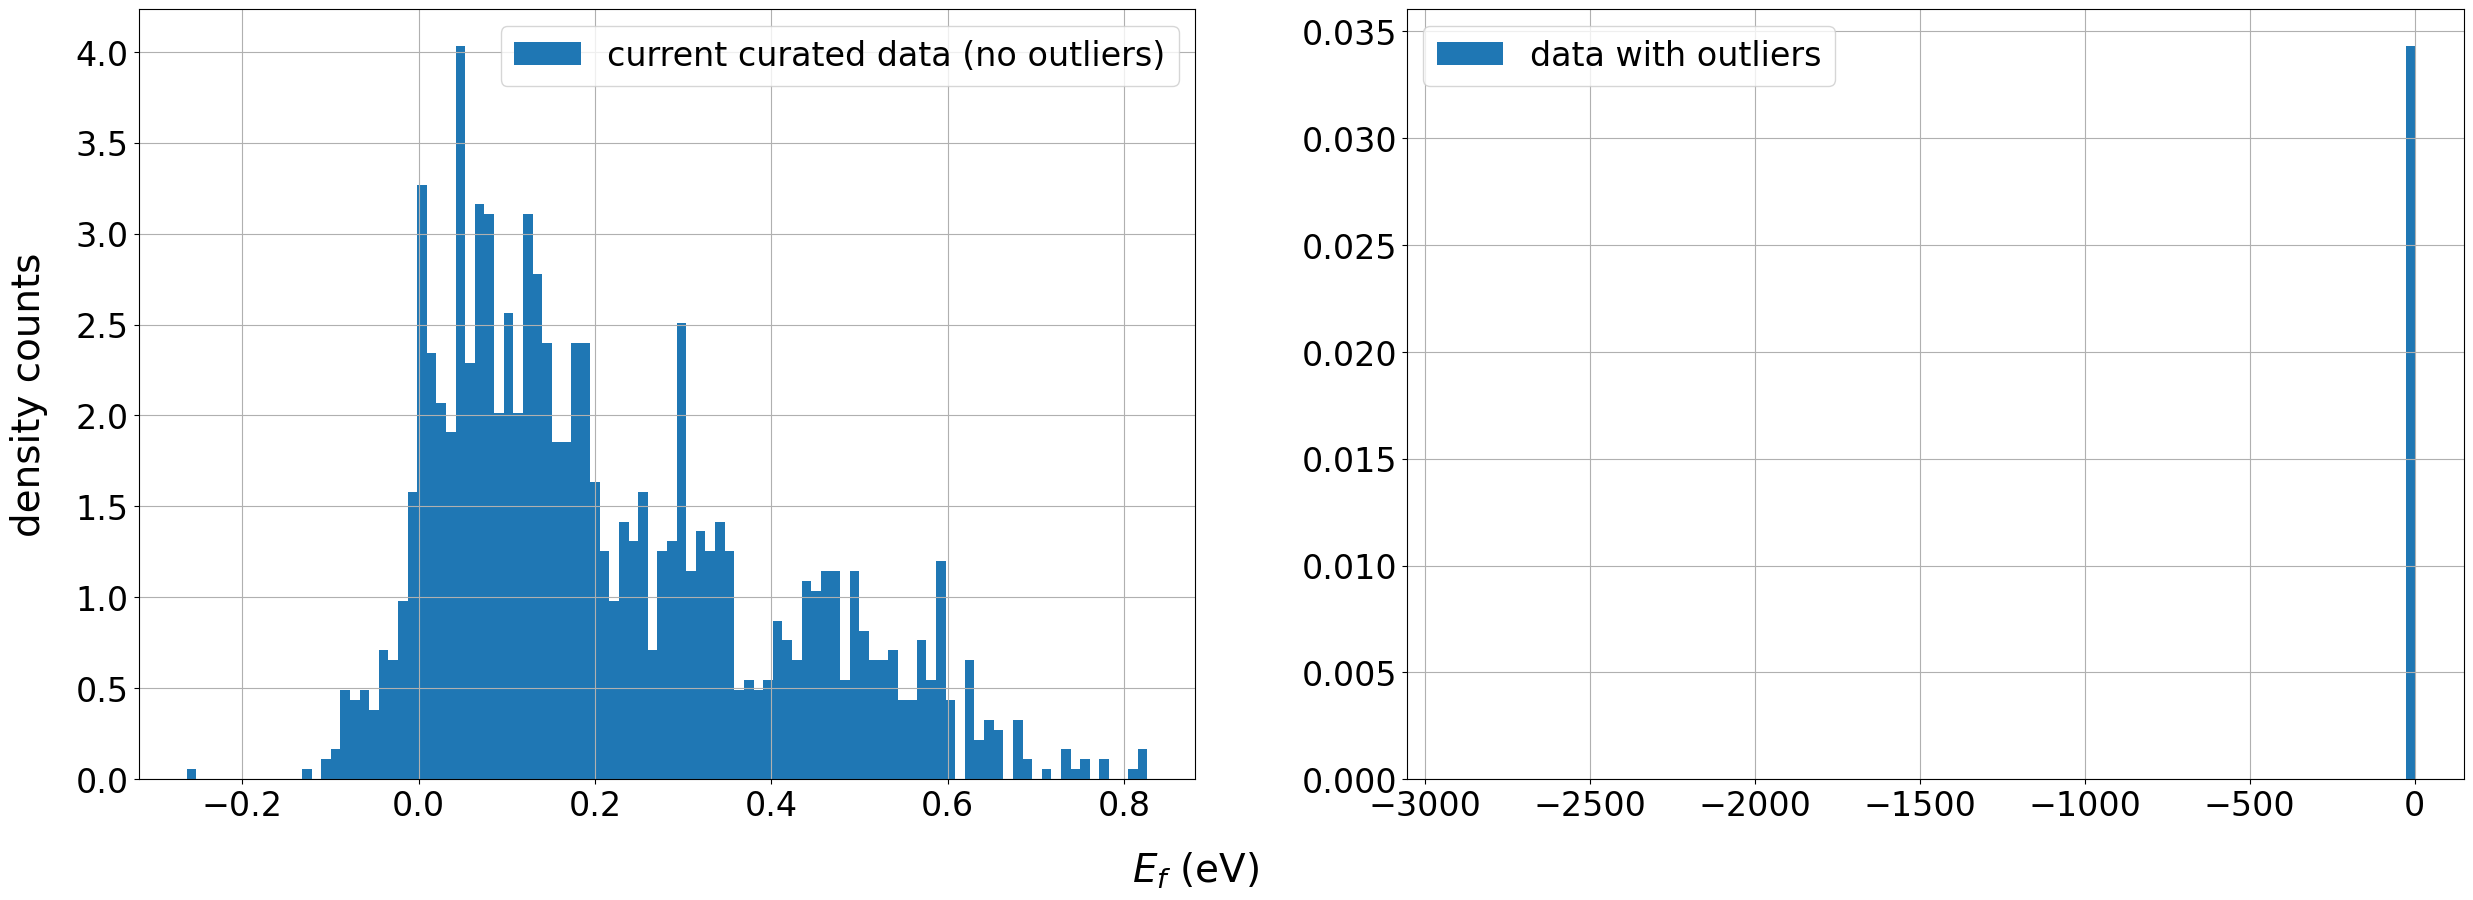

In [13]:
fig = with_and_without_outliers(DATA['EF'],low=-1, hig=2.0)

In [14]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [15]:
Out_In_First

,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,NSC_moments_9,...,NSC_bn_18,NSC_bn_19,NSC_bn_20,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv11W_sv2.mu-AAAAB.NM,0.0,1.779759,-0.575332,6.427369,-4.502642,31.837080,-34.624192,194.691246,-288.881477,1391.271385,...,0.0,0.0,0.0,-0.290871,1.505827,0.0,1013.263491,797.261714,-2908.966186,-2918.897693
Co_pv8W_sv4.C14-BAA.FM,0.0,2.496405,-0.957307,12.508827,-10.171457,85.054667,-109.894300,715.144333,-1293.729000,7053.914333,...,0.0,0.0,0.0,-0.369630,1.757653,2.0,-3.039032,347.454241,3.087797,-5.877353
Cr_pv10Co_pv4W_sv16.sigma-ABCCA.FM,0.0,1.934360,-0.644754,6.523645,-4.441069,27.740273,-27.454160,136.842400,-170.988120,751.079467,...,0.0,0.0,0.0,-0.175496,1.385139,2.0,-0.754852,780.349477,2.390903,-8.574481


In [16]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

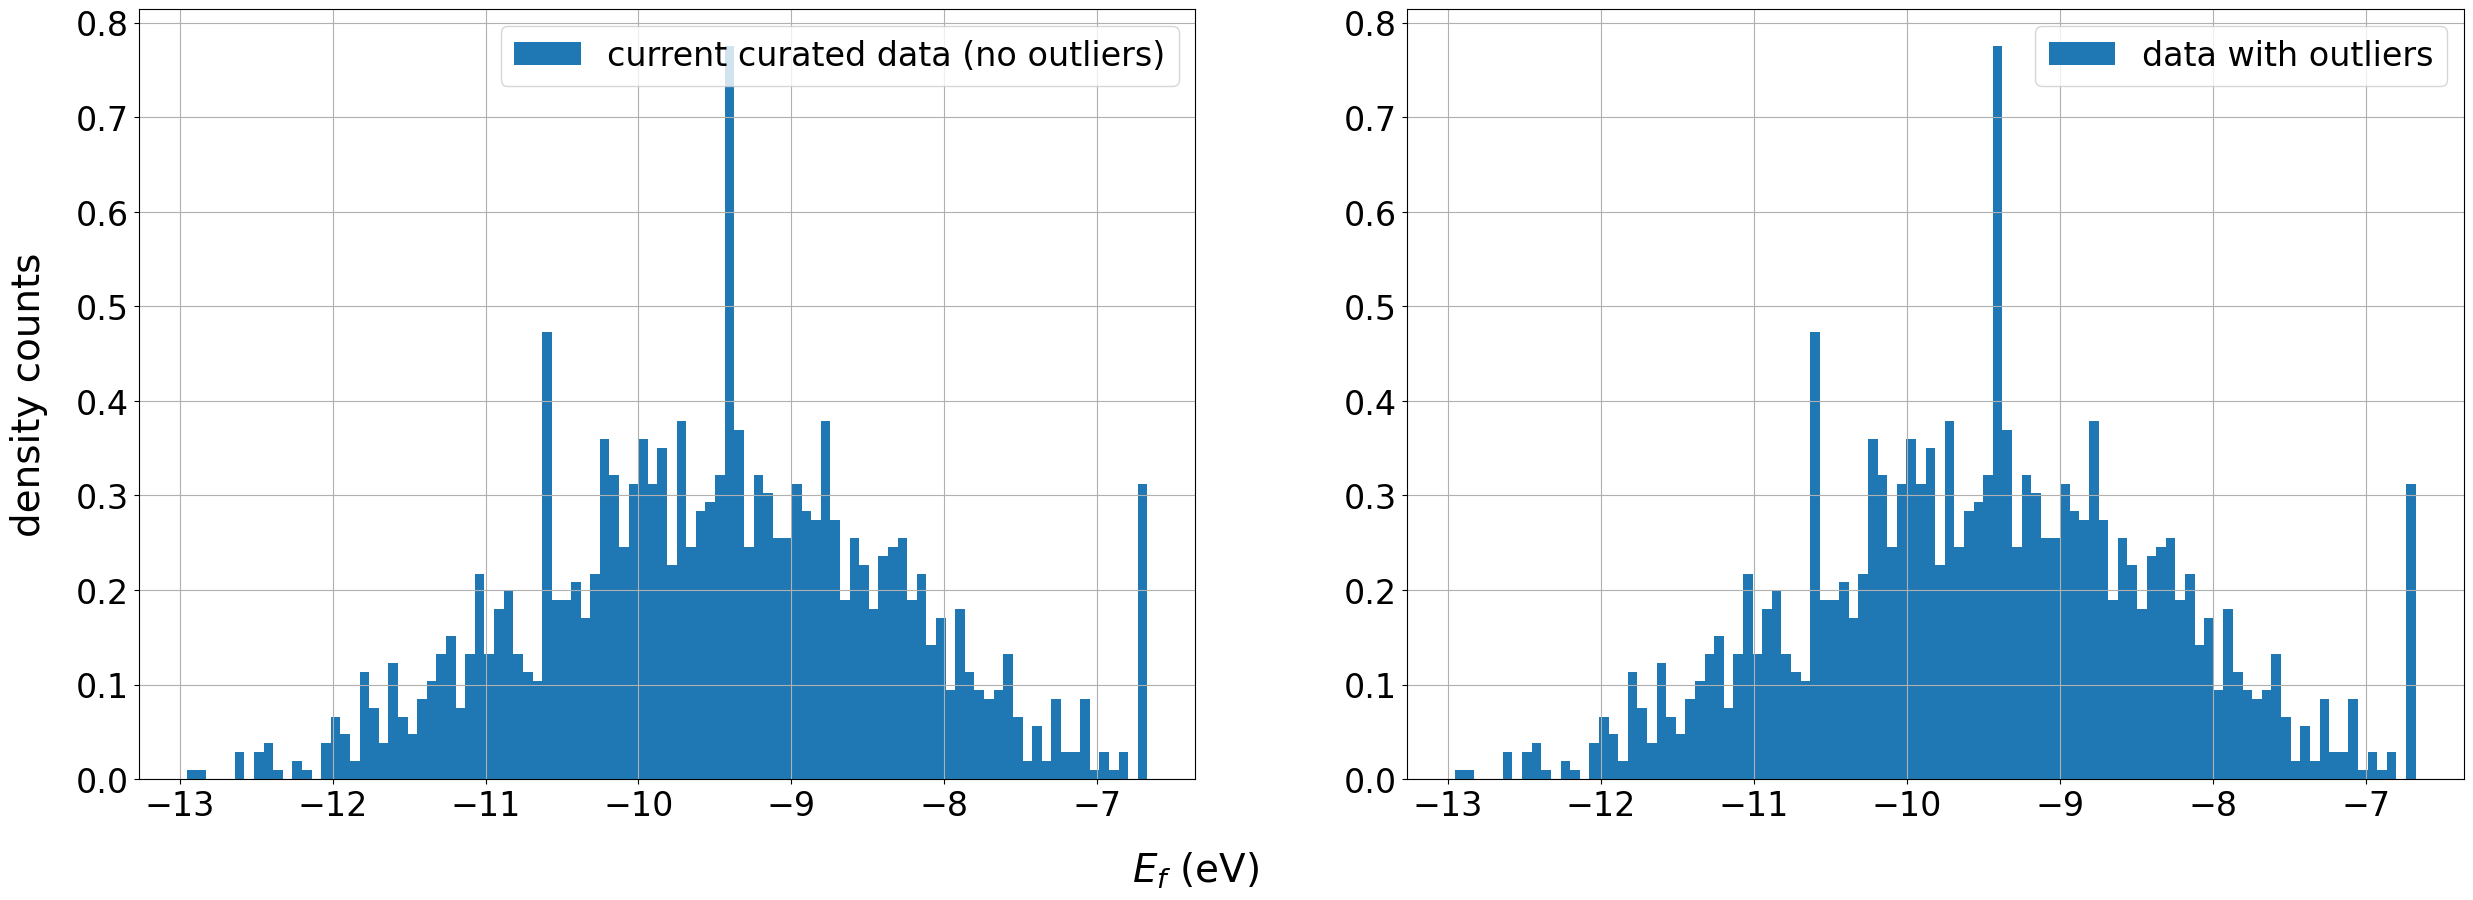

In [17]:
fige0 = with_and_without_outliers(DATA['E0'],low=-100, hig=10)

In [18]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [19]:
DATA.shape

(1684, 89)

### $E_0$ vs $\Delta E_{F}$

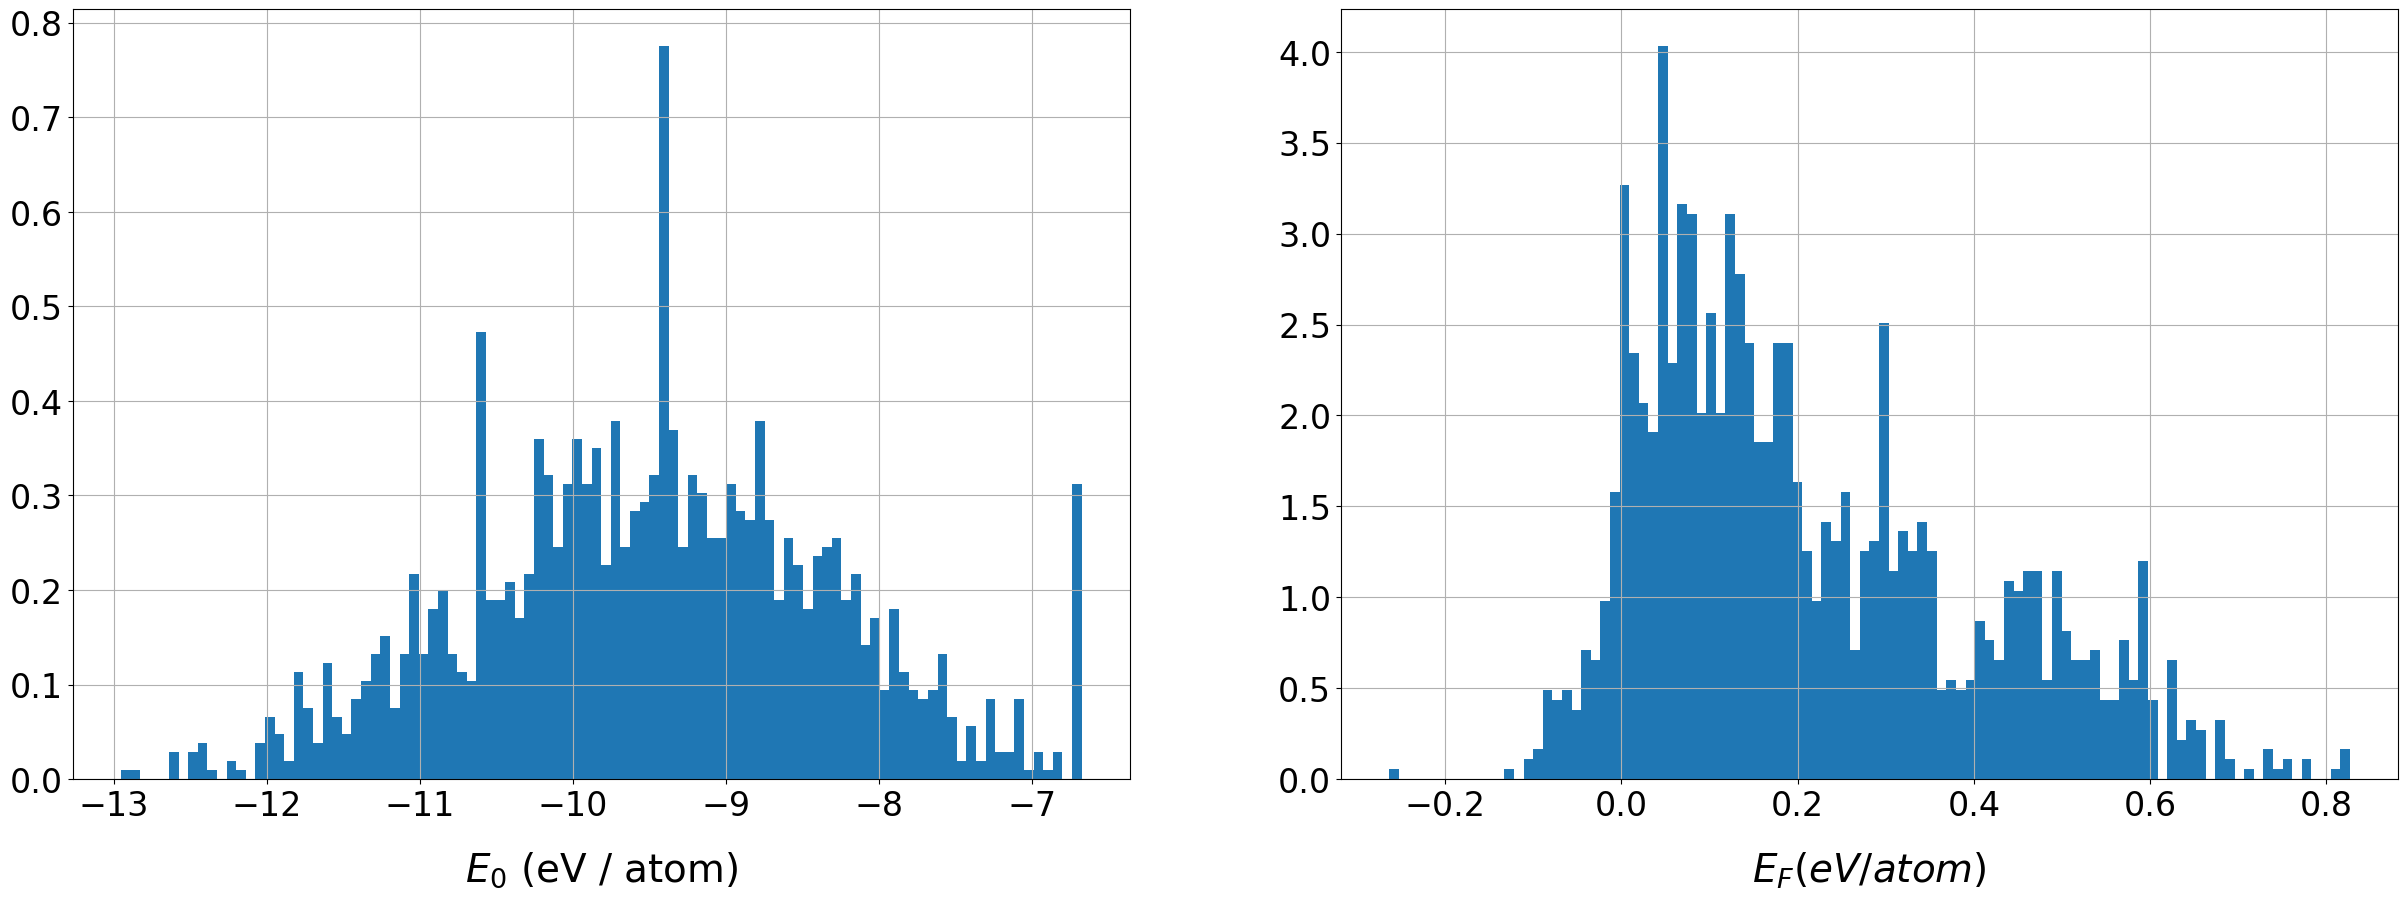

In [20]:
figcomp = compare_features(DATA['EF'],'$E_{F} (eV / atom)$', DATA['E0'],'$E_{0}$ (eV / atom)')

## B0

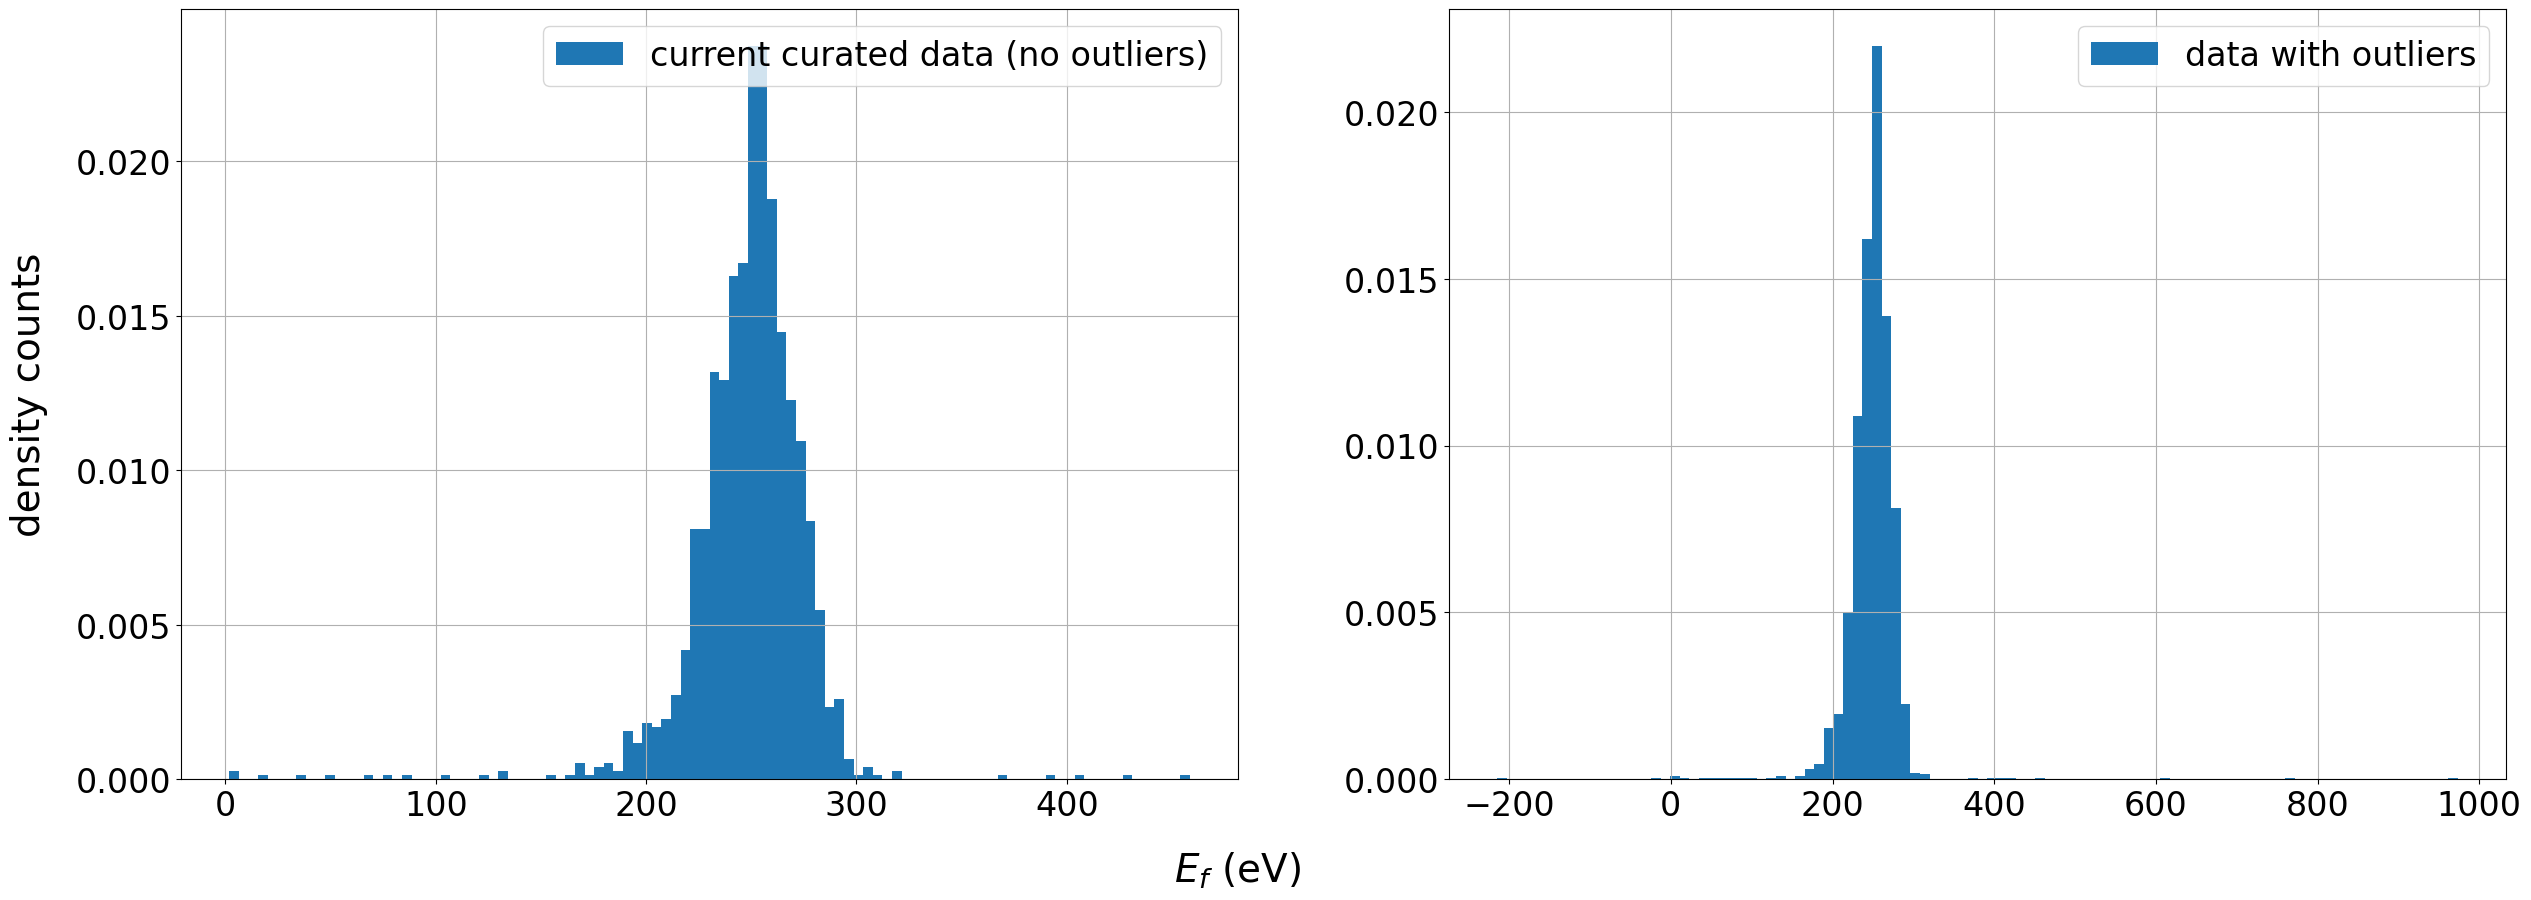

In [21]:
figB0 = with_and_without_outliers(DATA['B0'], low=0, hig=500)

In [22]:
DATA[(DATA['B0'])<0 | (DATA['B0']>500)]

,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,NSC_moments_9,...,NSC_bn_18,NSC_bn_19,NSC_bn_20,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv1Co_pv28.chi-ABBB.FM,0.0,2.212484,-0.737217,8.411234,-6.099602,38.993897,-43.659024,204.756862,-304.666483,1177.976552,...,0.0,0.0,0.0,-0.252484,1.316658,2.0,-19.618559,1.958360,0.217218,-6.836854
Cr_pv18Co_pv6.C36-AAABA.FM,0.0,1.909656,-0.651702,7.508902,-5.425544,41.216815,-48.025133,285.409500,-476.560667,2349.468167,...,0.0,0.0,0.0,-0.382666,1.564857,2.0,-214.604035,17.026433,0.175928,-8.603332


In [23]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

In [24]:
DATA.shape

(1682, 89)

## Drop Nans !

In [25]:
DATA.dropna(how='any', axis=0,inplace=True)

# Histograms of features

Are there more outliers ?

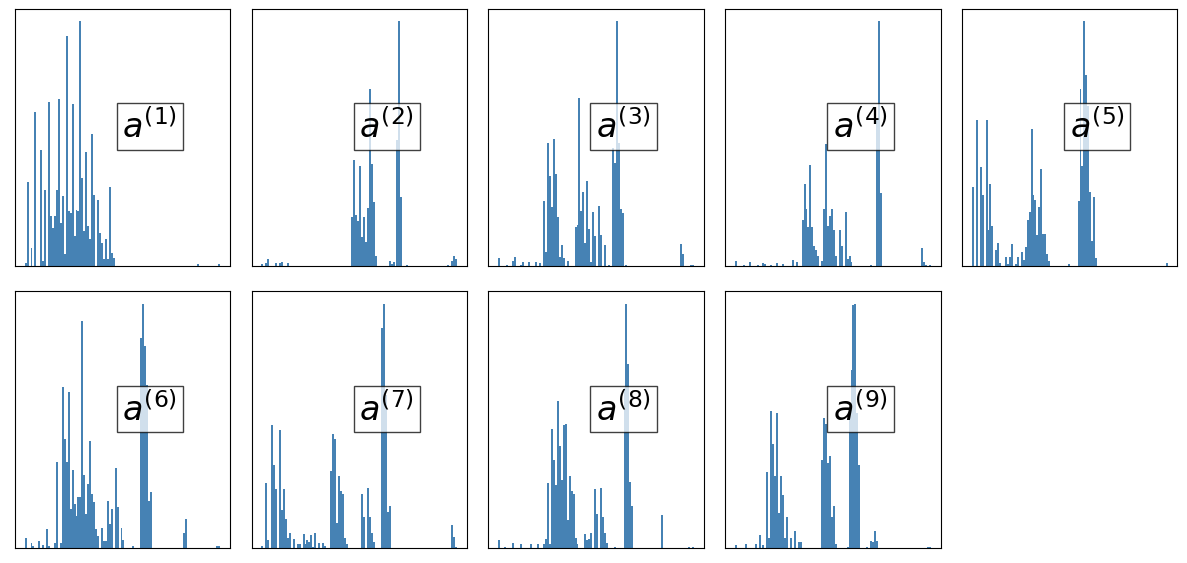

In [26]:
figure = HF.histoff_realfeatures(DATA,useful_an,feature_titles[useful_an], figsize_=(15,7))
figure.savefig(get_plot_filename('Histogram', 'an'))

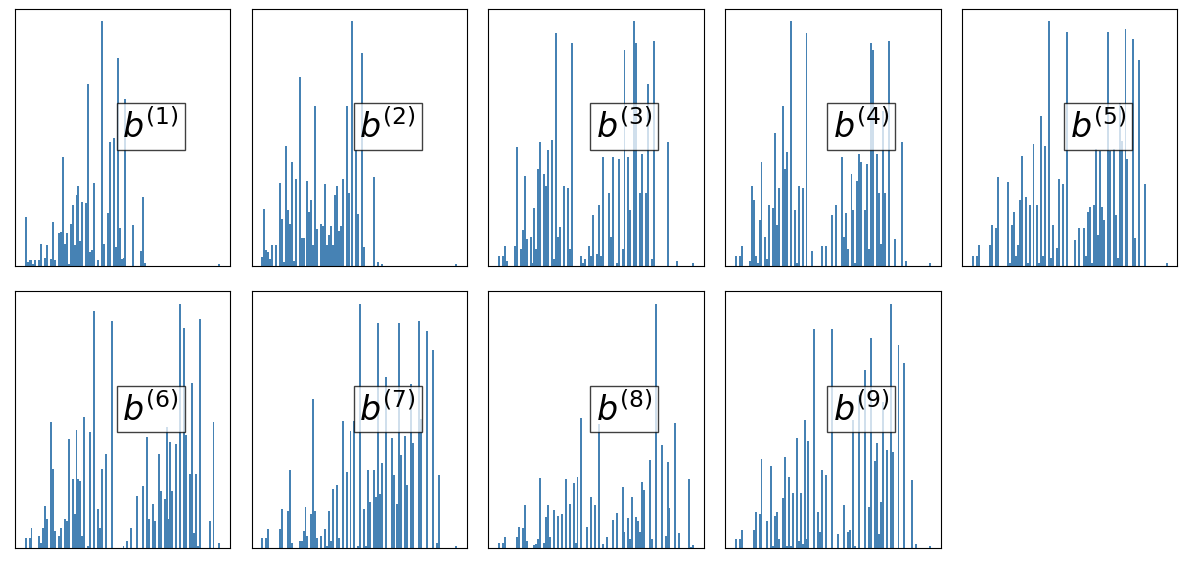

In [27]:
figure = HF.histoff_realfeatures(DATA,useful_bn[:-1],feature_titles[useful_bn],figsize_=(15,7))
figure.savefig(get_plot_filename('Histogram','bn'))

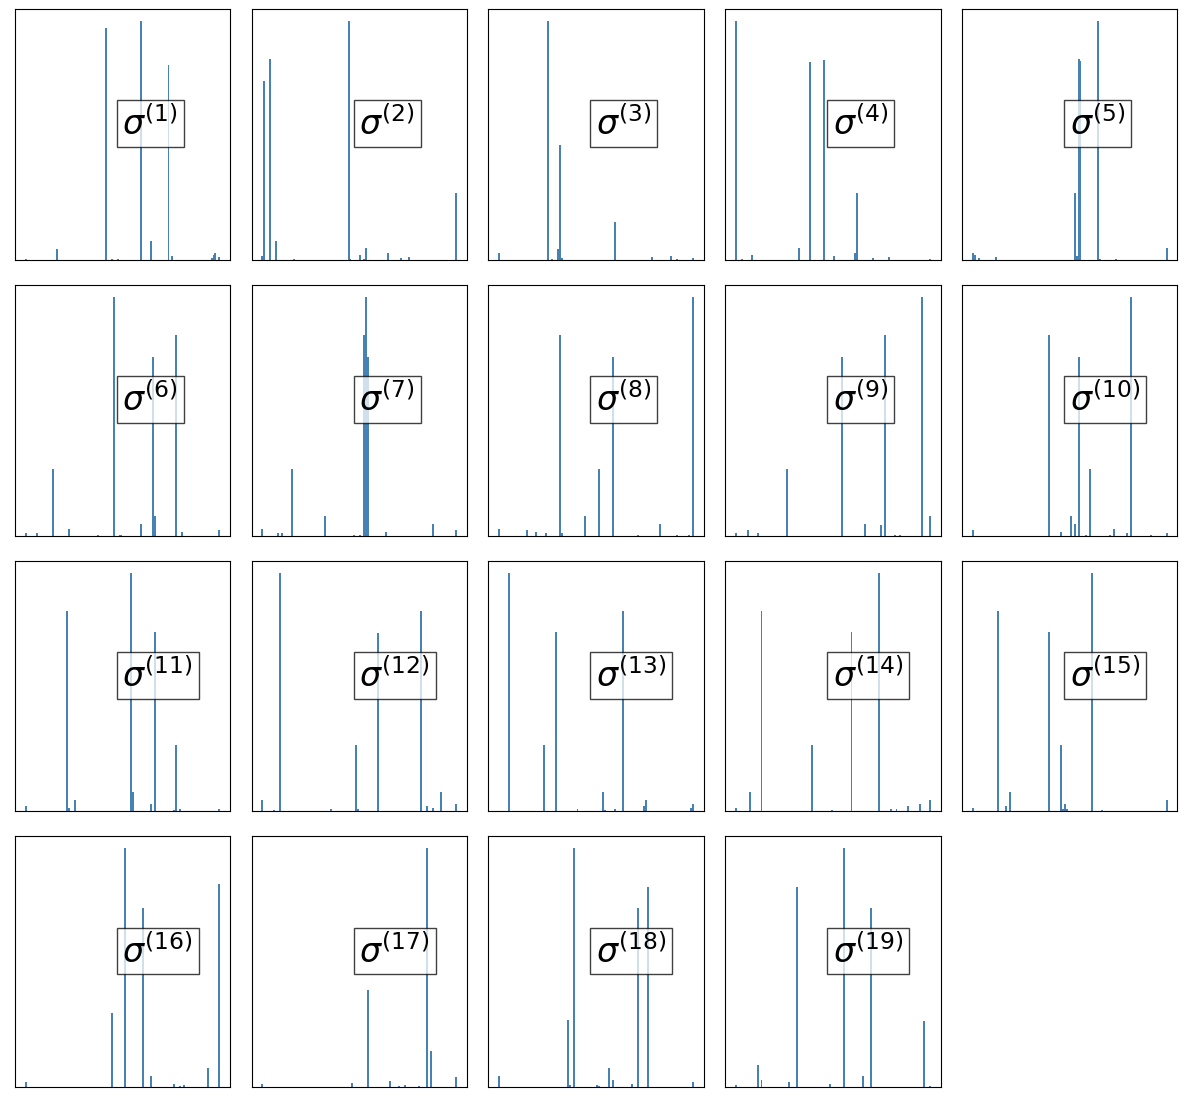

In [28]:
figure = HF.histoff_realfeatures(DATA,useful_sigmas,feature_titles[useful_sigmas],figsize_=(15,14))
figure.savefig(get_plot_filename('Histogram','sigmas'))

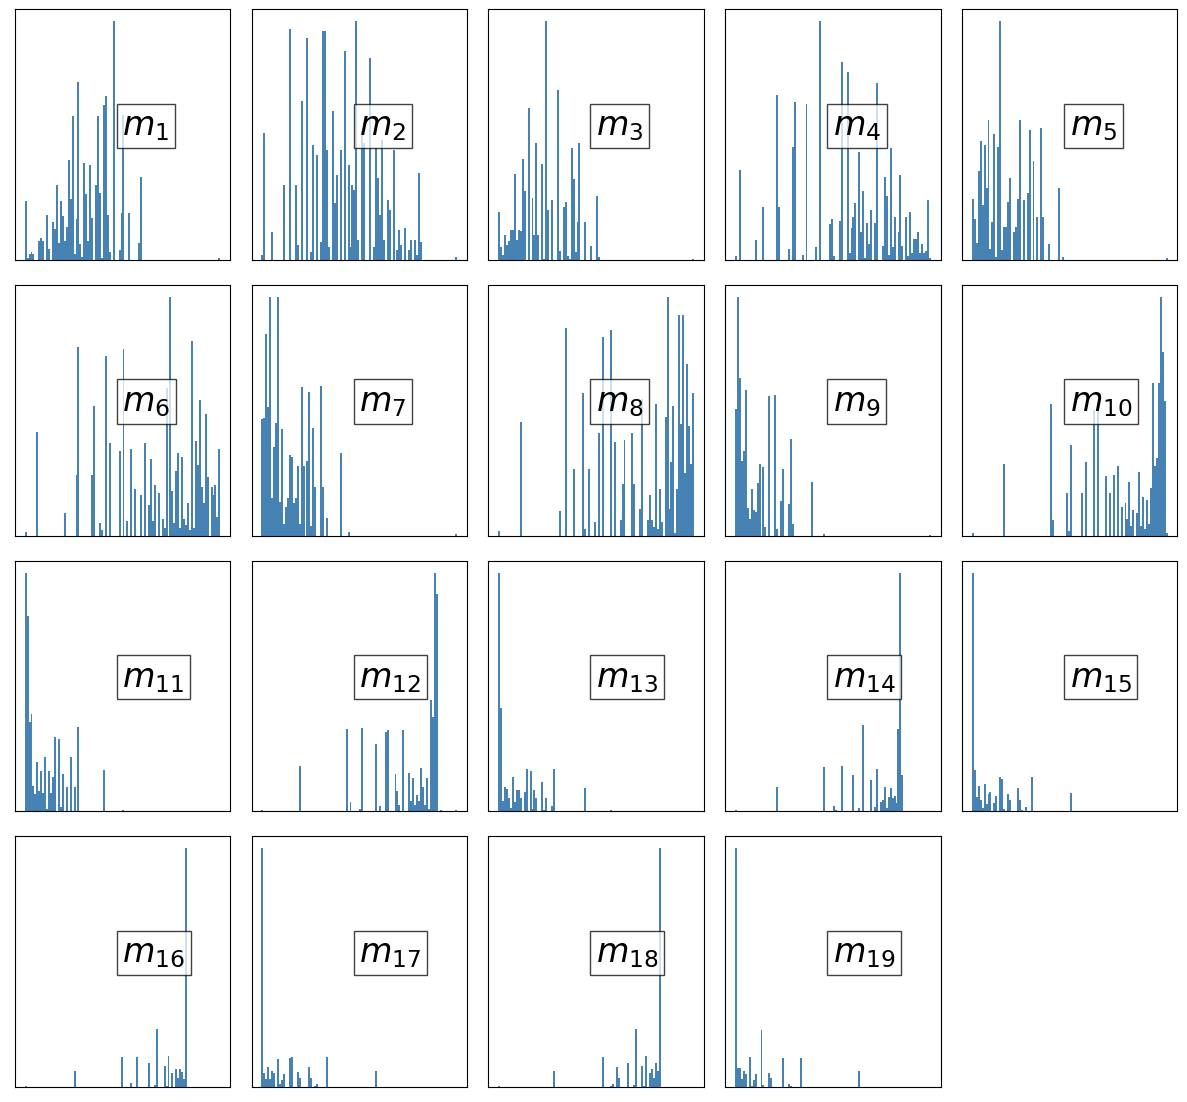

In [29]:
figure = HF.histoff_realfeatures(DATA,useful_moment,feature_titles[useful_moment],figsize_=(15,14))
figure.savefig(get_plot_filename('Histogram','moments'))

# Classification and weighting

Text(0, 0.5, '')

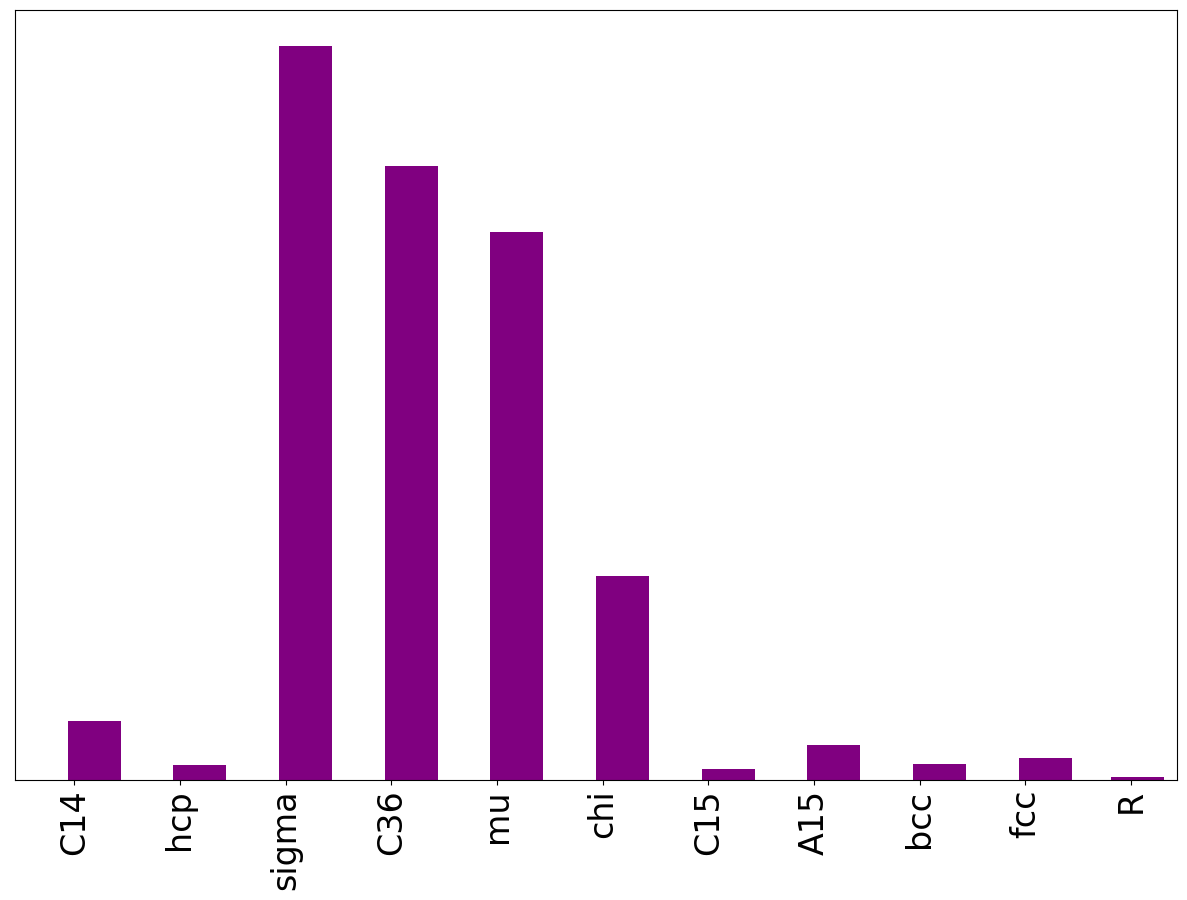

In [30]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [31]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

# Correlations

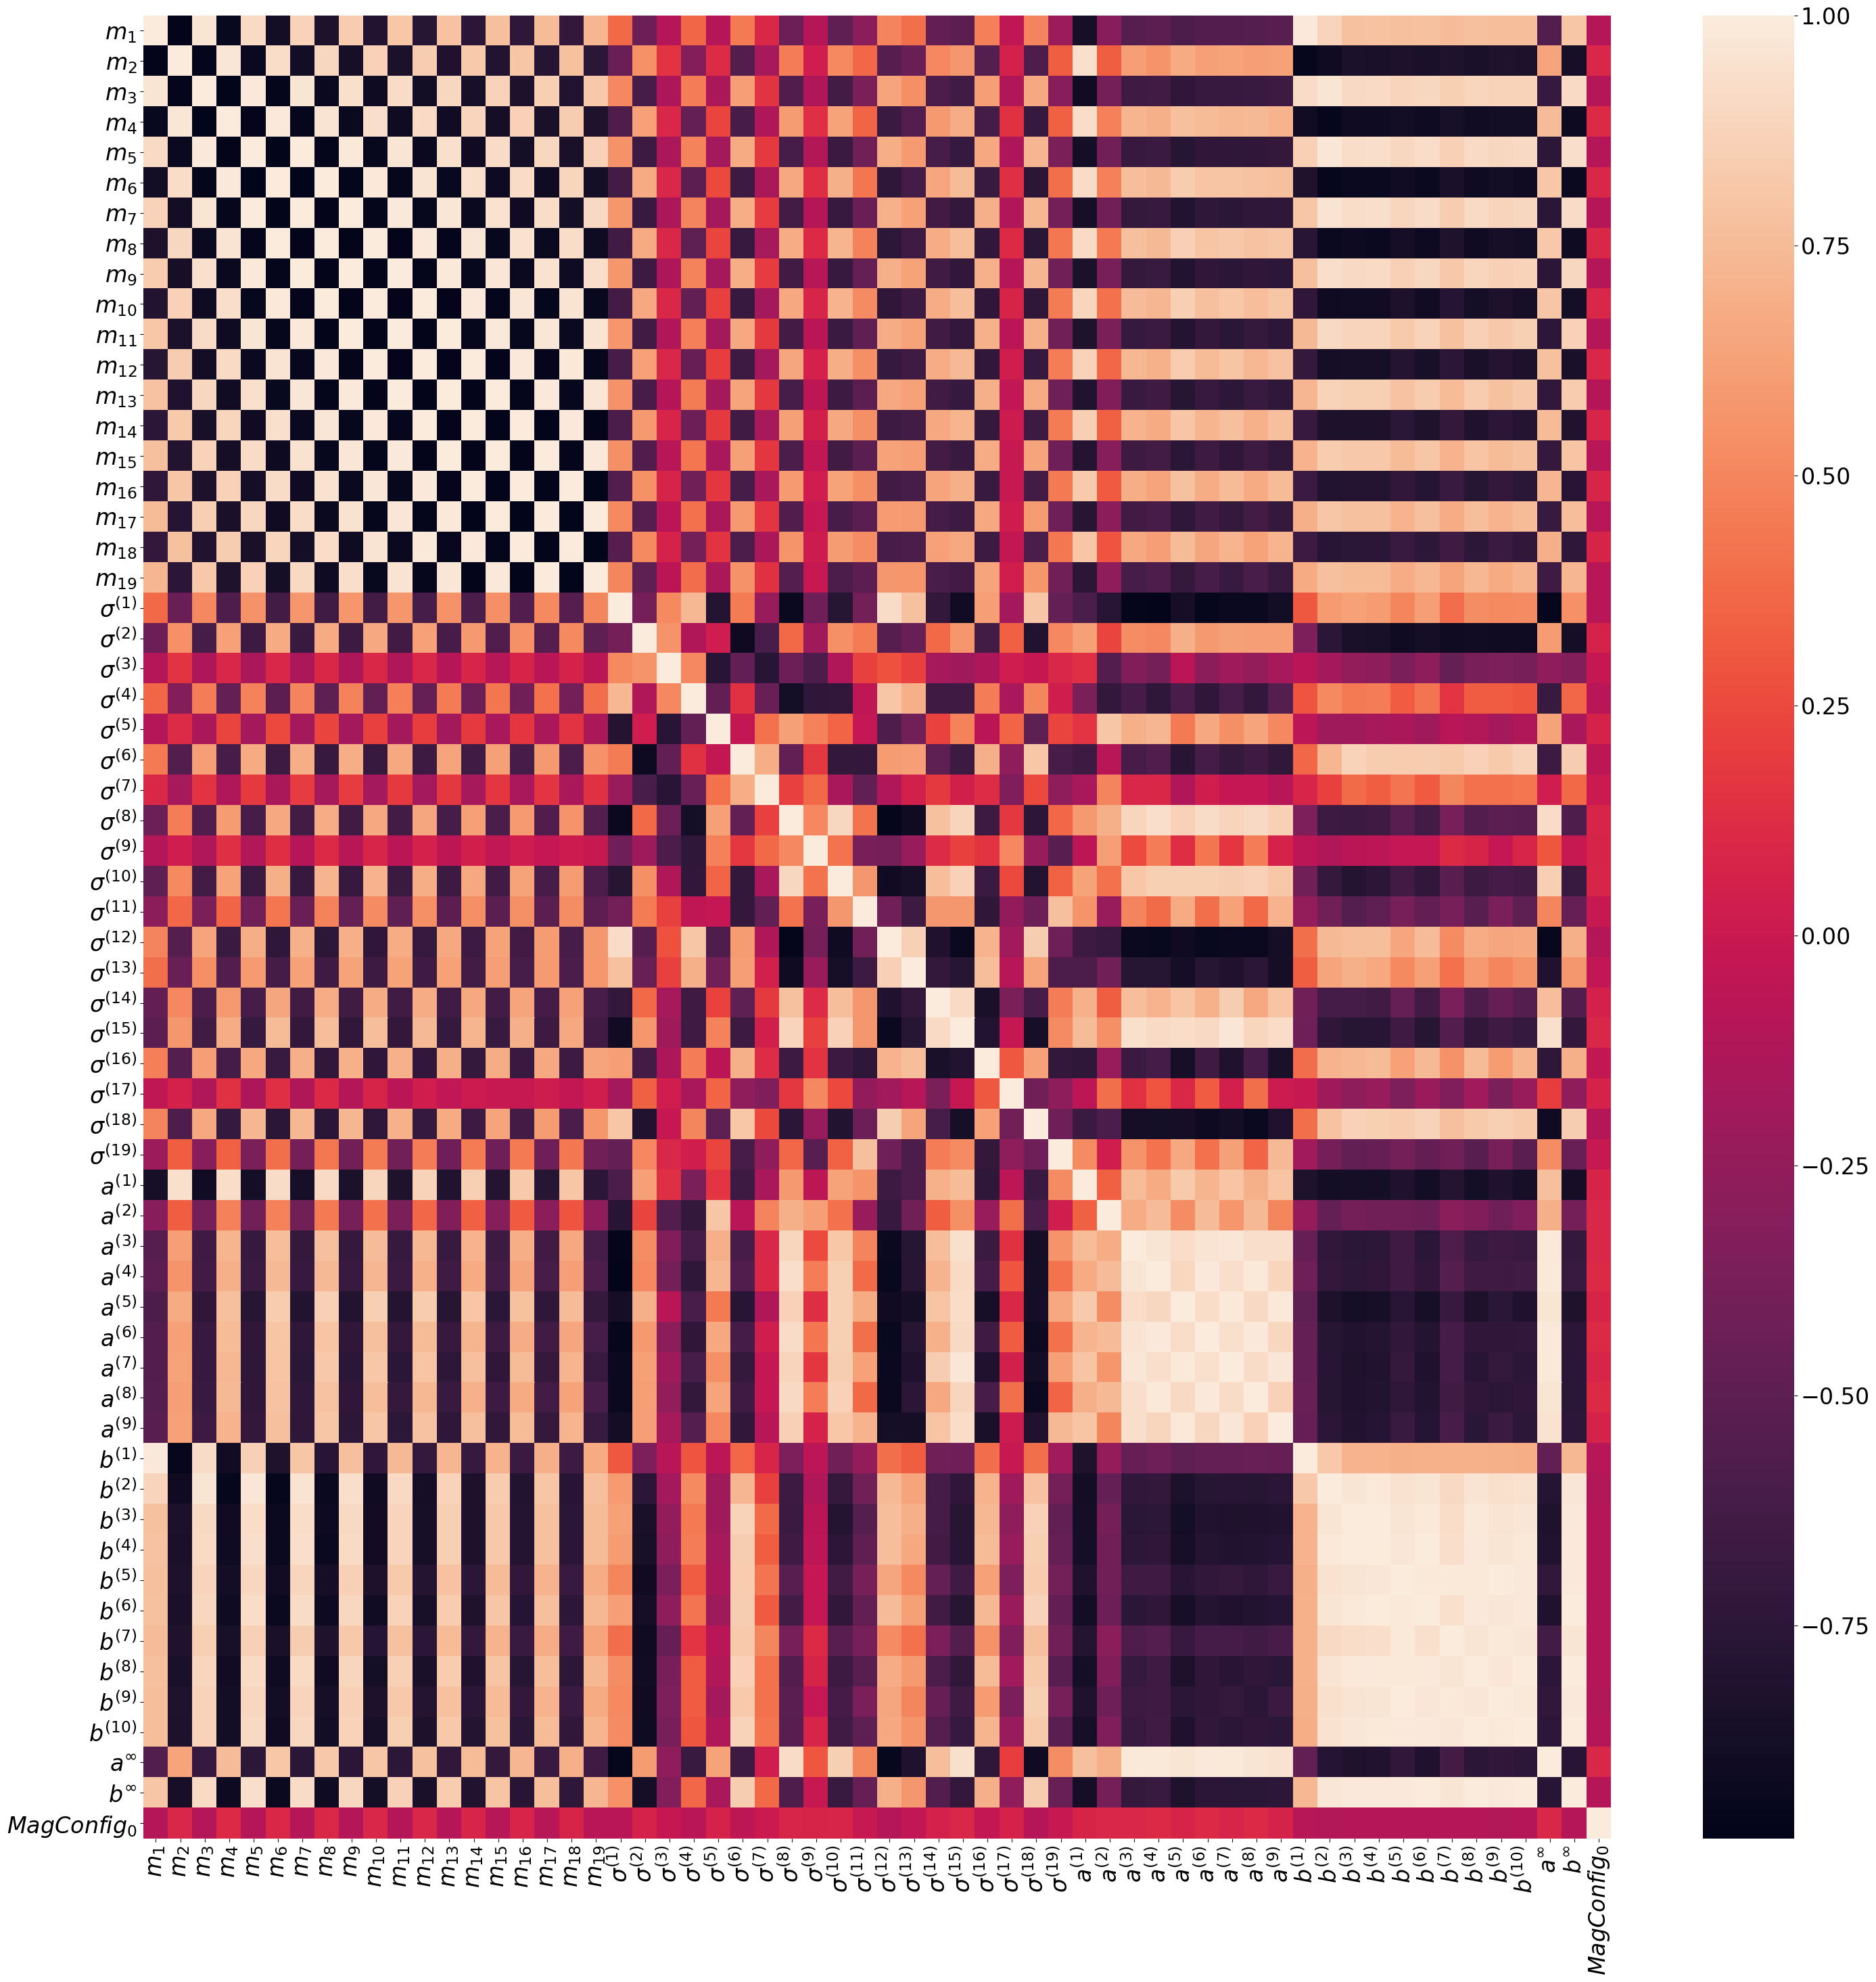

In [32]:
CORRS = DATA[real_feature+['EF']].corr()
fig, ax  = plt.subplots(1,1, figsize=(35,35))
HM = heatmap(CORRS, ax=ax)
labels = CORRS.columns #[s.get_text()  for s in HM.get_yticklabels()] 
ticklabels = [feature_titles[s] for s in labels]
xlabels = HM.set_yticklabels(ticklabels)
ylabels = HM.set_xticklabels(ticklabels)

In [33]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

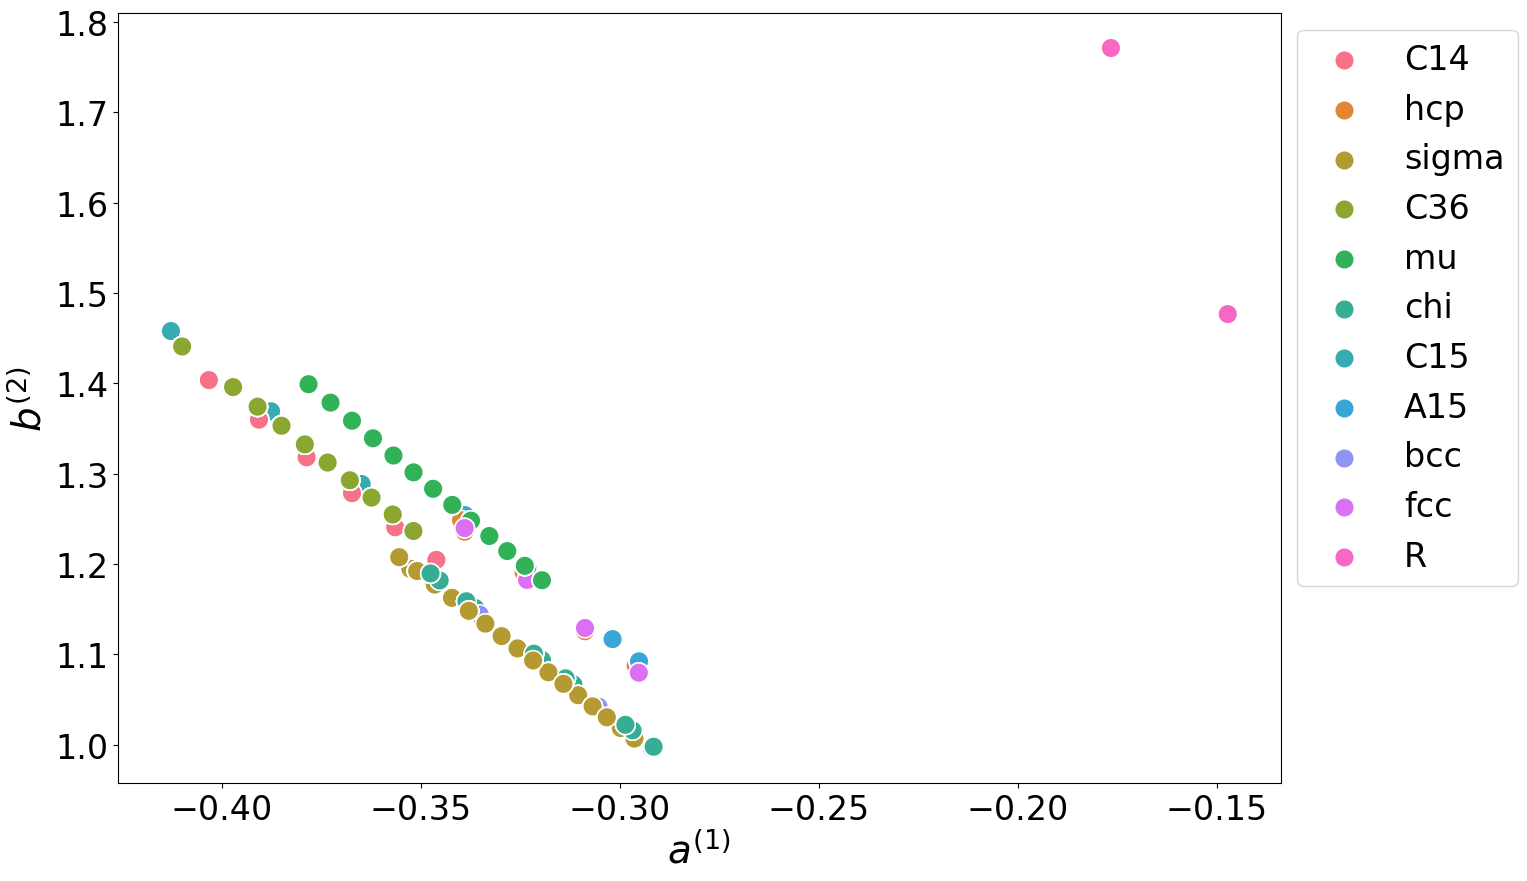

In [34]:
theone ='NSC_an_1' 
theother = 'NSC_bn_2'
fig1 = plot_pair(theone,theother ,huefeature='Class')
fig1.savefig(get_plot_filename('PlotPair','plotpair_{}_{}'.format(theone,theother)))

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [35]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler

## Helper Functions for ML

In [36]:
def plot_the_errors(THISERRORS,case):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(get_plot_filename('Errors_by_class', case))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, themodel):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA['EF'],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test['EF'],'o', label='test set')
    ax.plot(DATA['EF'], DATA['EF'],'-k')
    ax.legend()
    ax.set_xlabel('True $\Delta E_F$')
    ax.set_ylabel('predicted $\Delta E_F$')
    fig.savefig(get_plot_filename('Predictionline',themodel))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, thetarget):
    Y_predict_train = themodel.predict(X_train)
    Y_predict_test = themodel.predict(X_test)
    return {'train': mean_squared_error(Y_train[thetarget], Y_predict_train ,squared=False), 'test':  mean_squared_error(Y_test[thetarget], Y_predict_test,squared=False )}

def make_simple_pipe(model):
    simple_model = Pipeline([('regressor', model())])
    return simple_model

I need Lists of errors to compare methods

In [37]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [38]:
simple_model = {'E0': make_simple_pipe(RandomForestRegressor), 'EF': make_simple_pipe(RandomForestRegressor)}

X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[['EF','E0']],test_size=0.2, shuffle=True)

simple_model['EF'].fit(X_train, Y_train['EF']) #, sample_weight=w_train)

simple_model['E0'].fit(X_train, Y_train['E0']) #, sample_weight=w_train)

Pipeline(steps=[('regressor', RandomForestRegressor())])

feature_importancesEF = permutation_importance(fittedEF, DATA[real_feature], DATA['EF'], sample_weight=Classes['Weights'])
feature_importancesE0 = permutation_importance(fittedEF, DATA[real_feature], DATA['EF'], sample_weight=Classes['Weights'])
fig, ax = plt.subplots(figsize = (30,8))
#ax.bar(real_feature, permutation_importances_abs)
ax.bar(real_feature, importances,alpha=0.5)
ticklabels = ax.set_xticklabels(feature_titles[real_feature], fontsize=18)

features_with_importances_weights = pd.DataFrame(
    {'features':X_train.columns, 'importancies':simple_model.feature_importances_ } #, 'model':simple_model}
).sort_values(by='importancies', ascending=False)

In [39]:
mses['random forest regressor'] = {
    'E0': train_test_errors(simple_model['E0'],'E0'), 
    'EF': train_test_errors(simple_model['EF'],'EF')
}

In [40]:
mses

{'random forest regressor': {'E0': {'train': 1.0983605945558923,
   'test': 1.258376122317591},
  'EF': {'train': 0.15366986560578846, 'test': 0.17762642108337823}}}

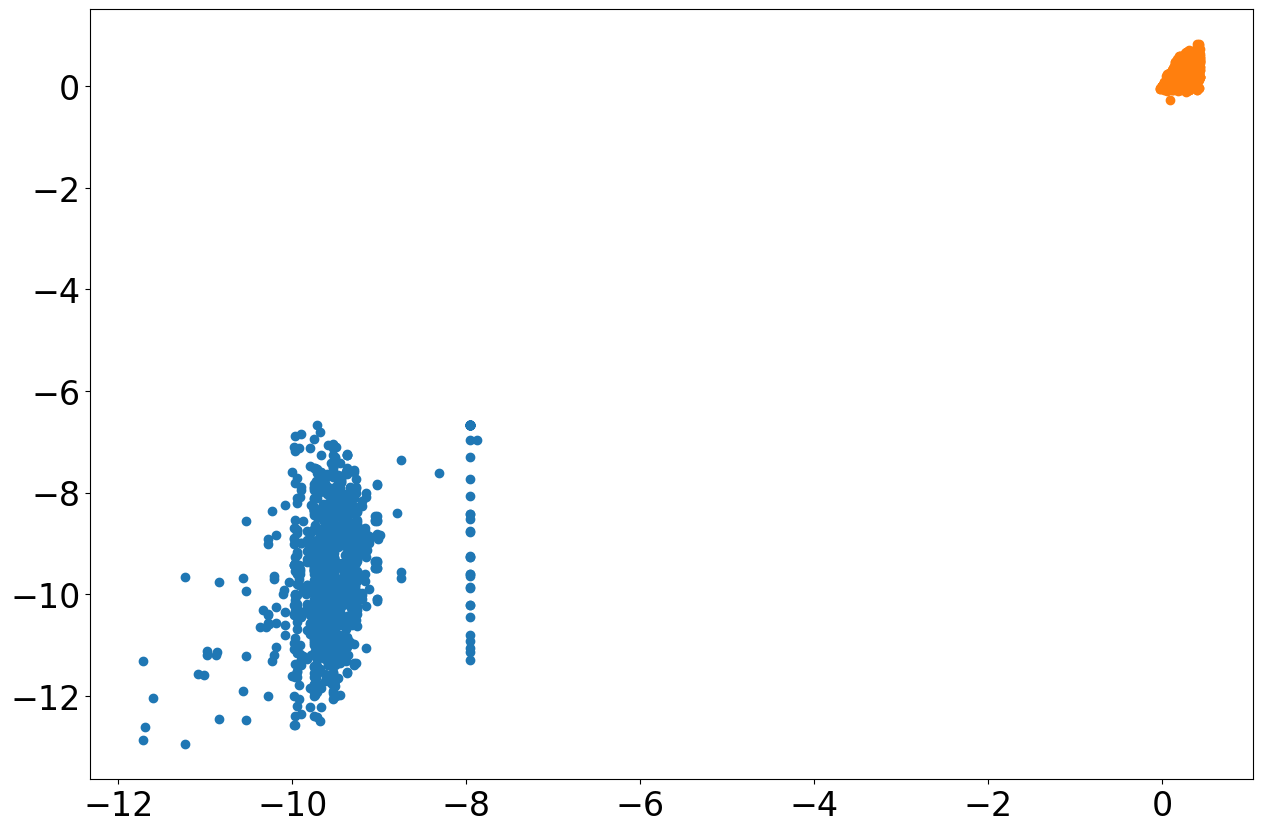

In [41]:
plt.plot(simple_model['E0'].predict(X_train),Y_train['E0'],'o')
plt.plot(simple_model['EF'].predict(X_train),Y_train['EF'],'o')

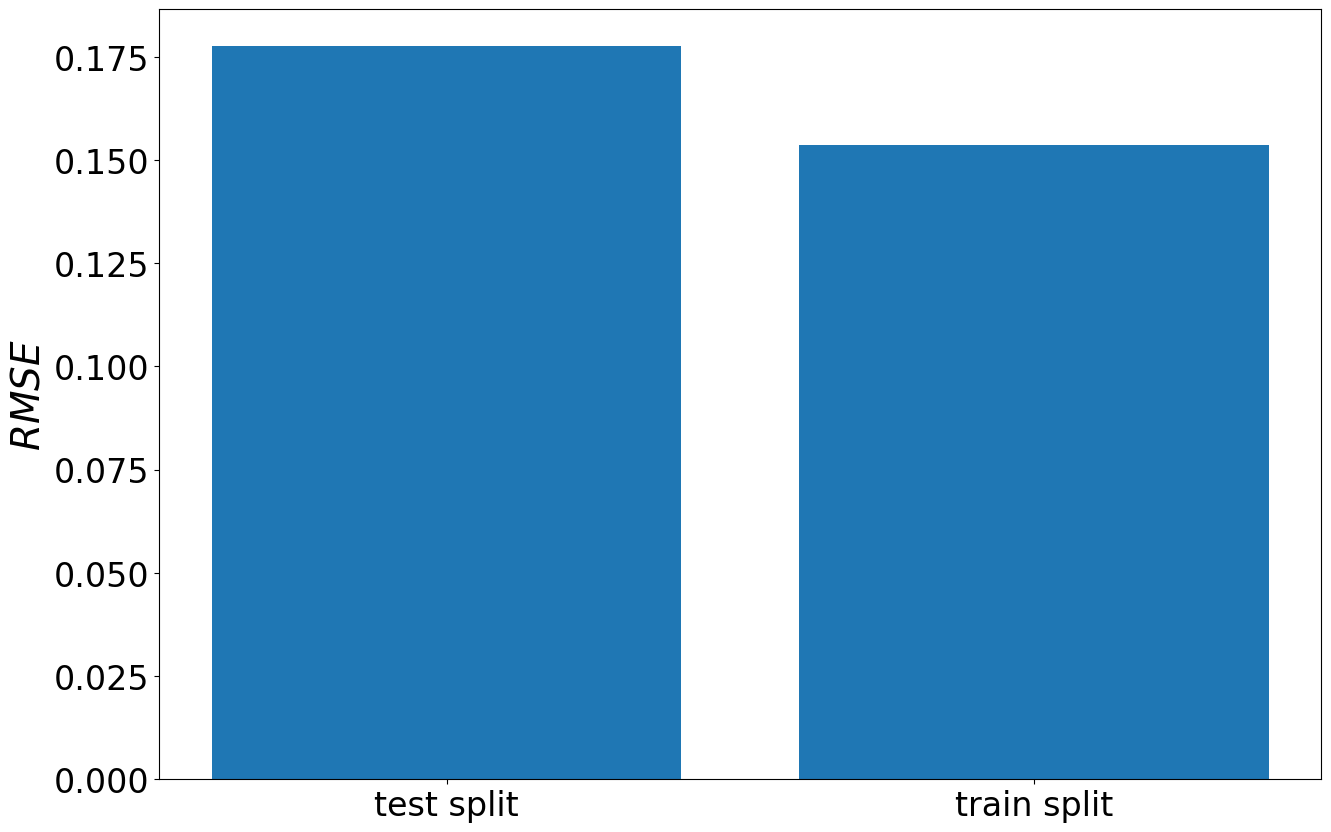

In [42]:
plt.bar(['test split','train split'],[mses['random forest regressor']['EF']['test'], mses['random forest regressor']['EF']['train']])
label = plt.ylabel('$RMSE$')

order = np.array(permutation_importances_abs).argsort()
#fig = plt.figure(figsize=(20,10))
plt.bar(feature_titles[np.array(real_feature)[order][-10:]], simple_model.feature_importances_[order][-10:])
plt.xlabel('Features')
plt.ylabel('Importances')

In [43]:
YPREDICT = simple_model['EF'].predict(DATA[real_feature])
Y_predict_test = simple_model['EF'].predict(X_test)
ERRORS = (YPREDICT - DATA['EF']).map(np.abs)

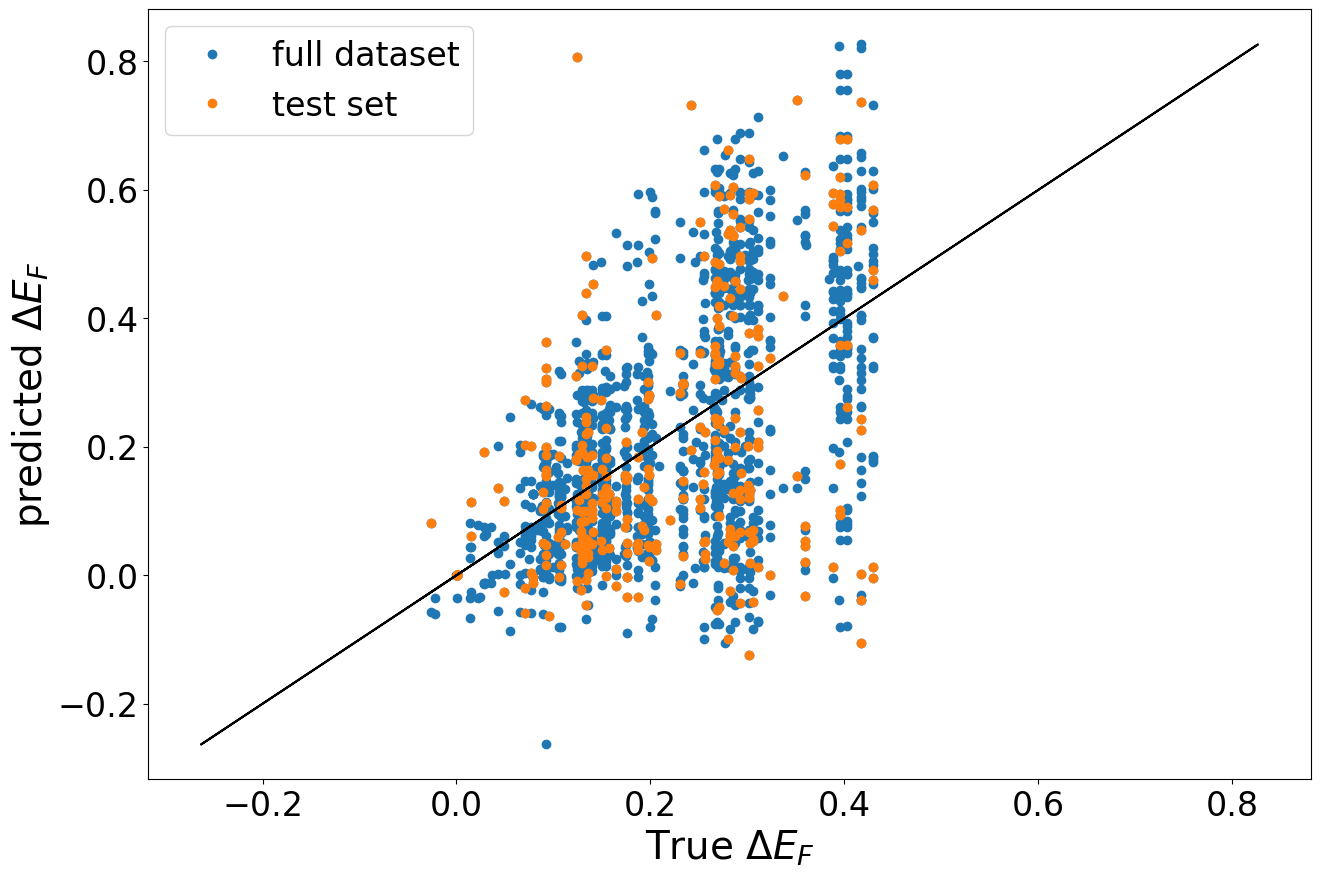

In [44]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

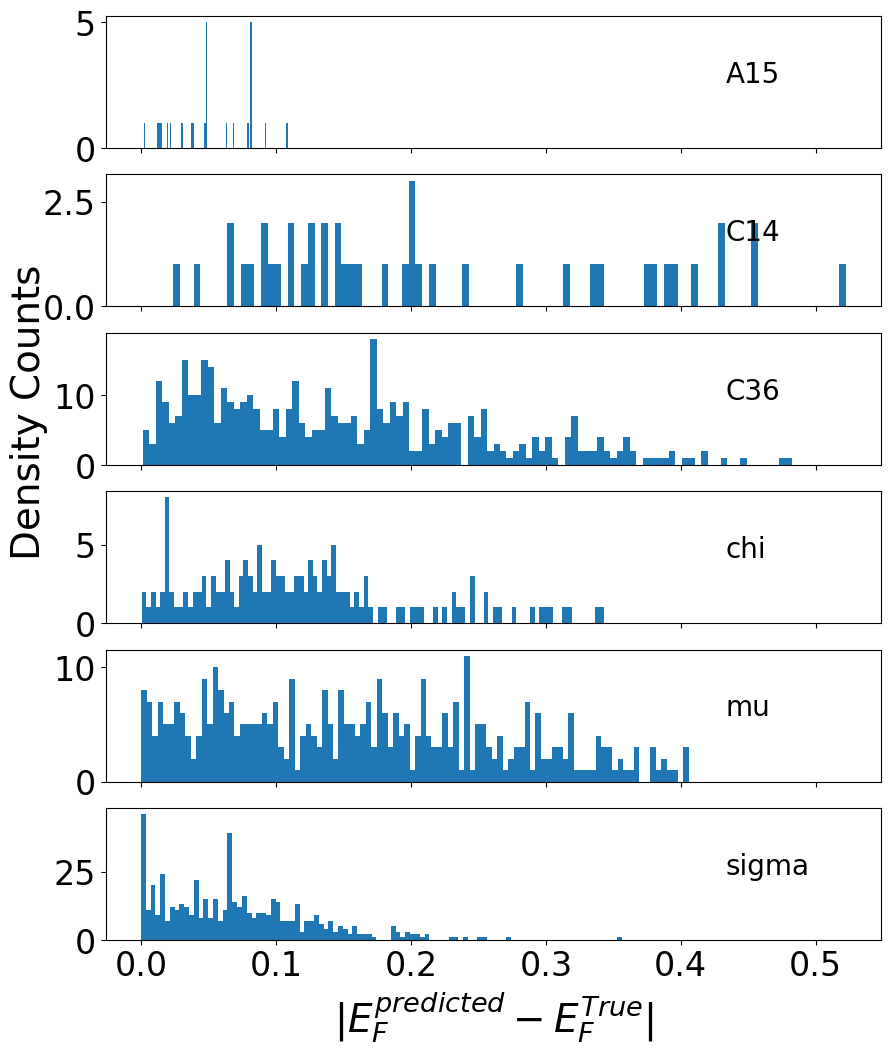

In [45]:
plot_the_errors(ERRORS,'RandomForestRegressor')

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

## Gaussian process

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
simple_model = Pipeline([('scaler', StandardScaler()),('regressor',GaussianProcessRegressor())])

In [48]:
fitted = simple_model.fit(X_train[real_feature], Y_train['EF'])

permutation_importances_abs = np.abs(permutation_importance(simple_model,DATA[real_feature],DATA['EF'], sample_weight=Classes['Weights'])['importances_mean'])

In [49]:
Y_predict_train = simple_model.predict(X_train)
Y_predict_test = simple_model.predict(X_test)
mses['gaussian process regressor'] = {
    'EF': {'train': mean_squared_error(Y_train['EF'], Y_predict_train ,squared=False),
           'test': mean_squared_error(Y_test['EF'], Y_predict_test,squared=False )
          }
}

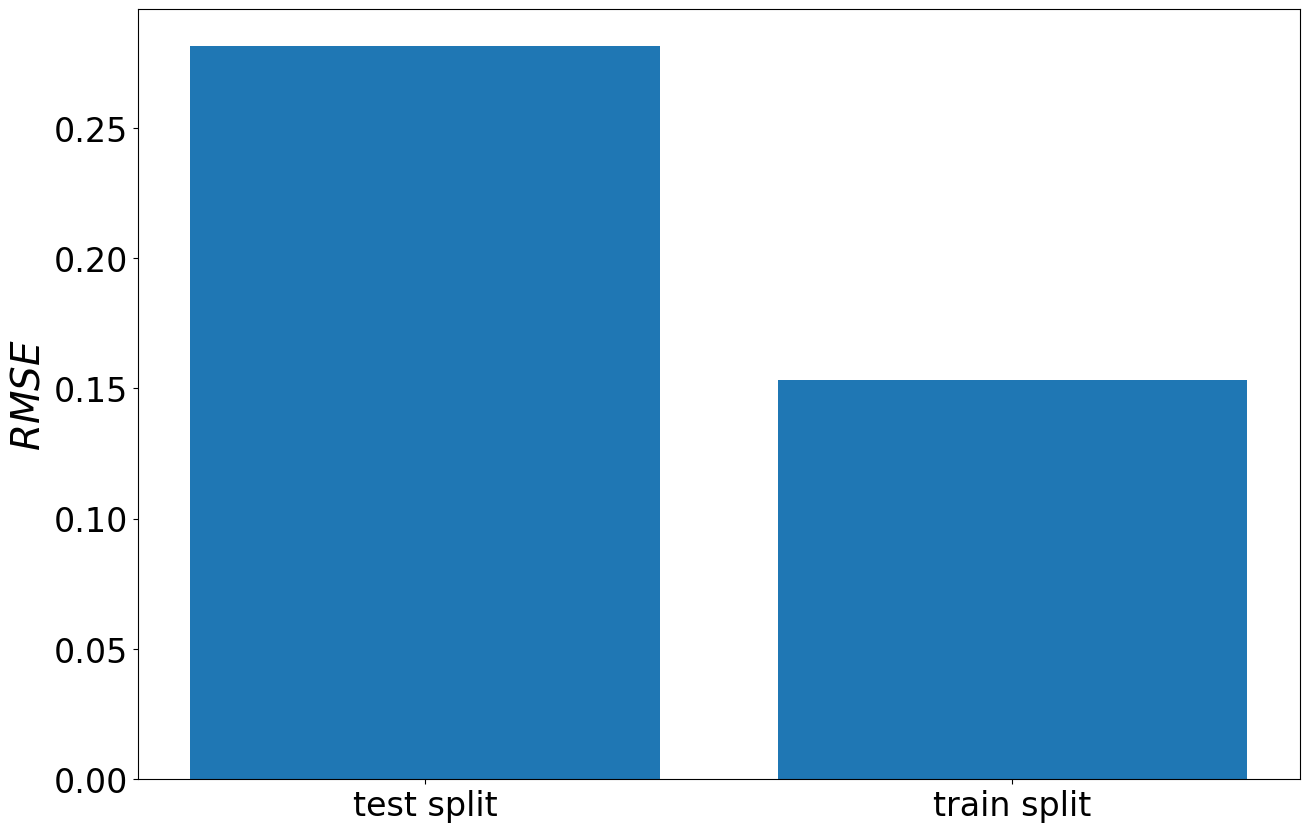

In [50]:
plt.bar(['test split','train split'],[mses['gaussian process regressor']['EF']['test'], mses['gaussian process regressor']['EF']['train']])
label = plt.ylabel('$RMSE$')

In [51]:
YPREDICT, ERR = simple_model.predict(DATA[real_feature],return_std=True)

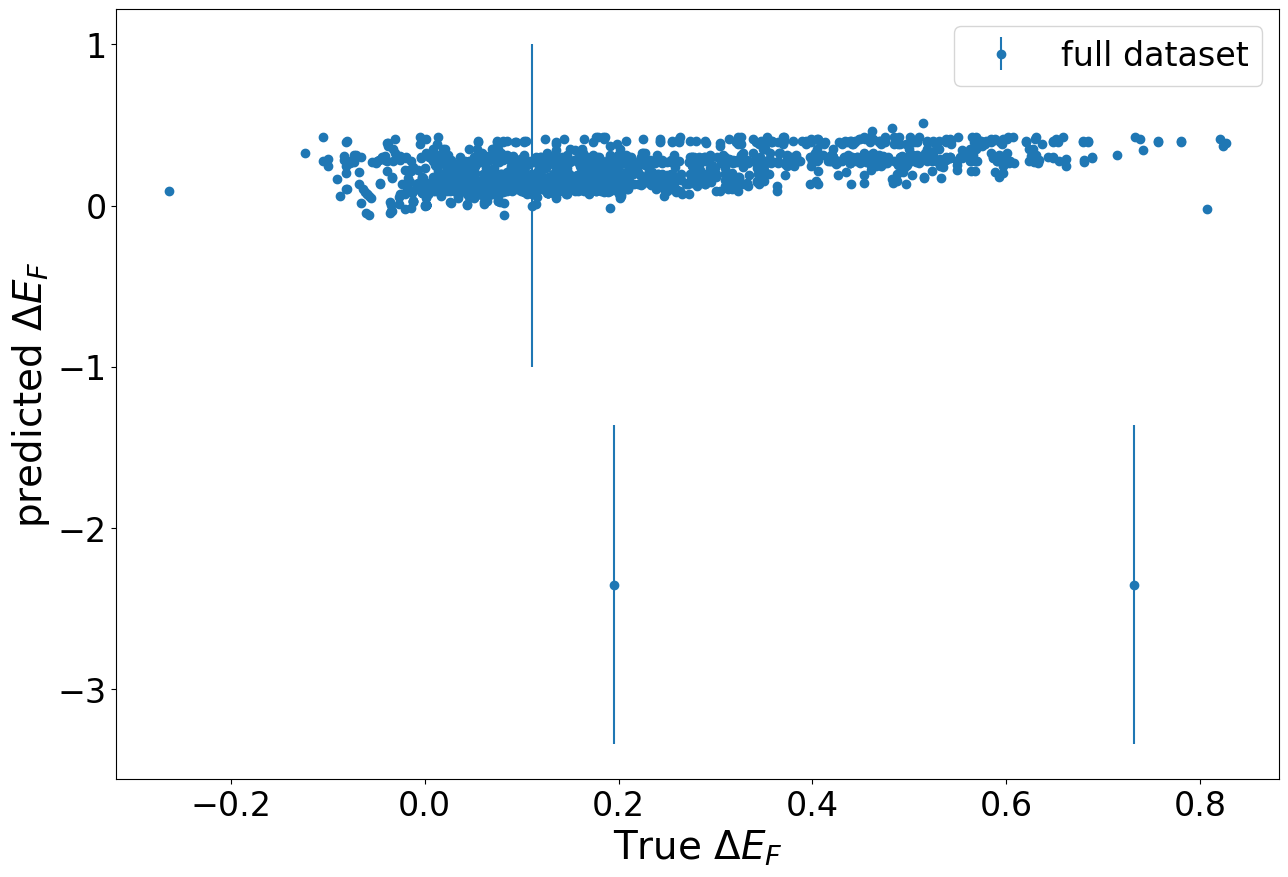

In [52]:
plt.errorbar(DATA['EF'], YPREDICT, yerr=ERR, fmt='o', label='full dataset')
plt.legend()
plt.xlabel('True $\Delta E_F$')
plt.ylabel('predicted $\Delta E_F$')
plt.savefig('simple_regresion.pdf')

In [53]:
ERRORS = (YPREDICT - DATA['EF']).map(np.abs)

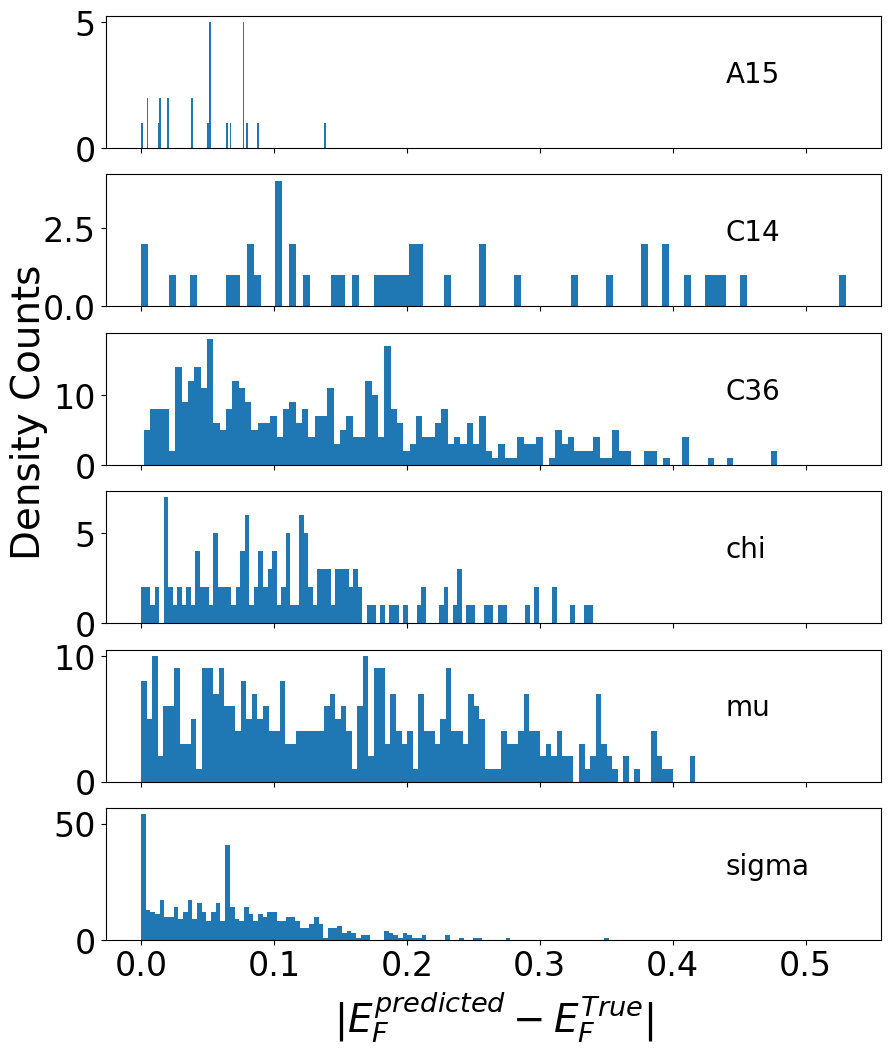

In [54]:
plot_the_errors(ERRORS,'gaussian_process')

# Feature Selection

In [55]:
Bestfeats = {}
Bestscores = {}
FC={}
criterion = 'test_score'

## Random Forest

In [56]:
useful_feature = useful_an+useful_bn+useful_moment+useful_sigmas+\
                ['MagConfig_0','NSC_Ainf_0', 'NSC_Binf_0']

In [73]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[useful_feature+['EF']],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=useful_feature,
    data_target='EF',
    criterion = criterion,
    sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
#    best_feature_proposal= proposal,
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

procesing '[]' with 'NSC_SIGMA_10' ... ::   0%|                                                  | 0/60 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'NSC_moments_8' ... :: 100%|########################################| 60/60 [00:51<00:00,  1.16it/s]


fitting has finished,  test_score  =  0.18121407946334908


procesing '['NSC_Binf_0']' with 'NSC_SIGMA_10' ... ::   0%|                                      | 0/33 [00:00<?, ?it/s]

...

fitting has finished,  test_score  =  0.17729473352166358
Refitting ..


procesing '['NSC_Binf_0', 'MagConfig_0', 'NSC_Ainf_0', 'NSC_SIGMA_3']' with 'NSC_SIGMA_17' ... :: 100%|#| 3/3 [00:03<00:
procesing '['NSC_Binf_0', 'MagConfig_0', 'NSC_Ainf_0', 'NSC_SIGMA_3', 'NSC_SIGMA_7']' with 'NSC_SIGMA_9' ... ::   0%| | 

fitting has finished,  test_score  =  0.17773146211901059
Refitting ..


procesing '['NSC_Binf_0', 'MagConfig_0', 'NSC_Ainf_0', 'NSC_SIGMA_3', 'NSC_SIGMA_7']' with 'NSC_SIGMA_17' ... :: 100%|#|

fitting has finished,  test_score  =  0.17788179461722534


In [74]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [75]:
thisdata

,0,1
0,NSC_Binf_0,0.17284695197977296
1,MagConfig_0,0.1784336881758214
2,NSC_Ainf_0,0.17712158635693168
3,NSC_SIGMA_3,0.17735059295249617
4,NSC_SIGMA_7,0.17773146211901059
5,NSC_SIGMA_9,0.17788179461722534


In [76]:
thisdata.to_csv(
    get_table_filename('BopFeatures',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [61]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target='EF',
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
#    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

procesing '[]' with 'NSC_an_2' ... ::   0%|                                                      | 0/19 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'NSC_bn_5' ... :: 100%|#############################################| 19/19 [00:16<00:00,  1.17it/s]


fitting has finished,  test_score  =  0.17140978852501731


procesing '['NSC_an_4']' with 'NSC_bn_3' ... ::   0%|                                            | 0/10 [00:00<?, ?it/s]

Refitting ..


procesing '['NSC_an_4']' with 'NSC_bn_5' ... :: 100%|###################################| 10/10 [00:08<00:00,  1.14it/s]

fitting has finished,  test_score  =  0.1706296281599927


In [62]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target='EF',
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
#    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

procesing '[]' with 'NSC_bn_8' ... ::   0%|                                                      | 0/10 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'NSC_bn_5' ... :: 100%|#############################################| 10/10 [00:08<00:00,  1.14it/s]

fitting has finished,  test_score  =  0.1724671383530104


In [63]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target='EF',
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
#    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

procesing '[]' with 'NSC_SIGMA_10' ... ::   0%|                                                  | 0/19 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'NSC_SIGMA_7' ... :: 100%|##########################################| 19/19 [00:14<00:00,  1.32it/s]
procesing '['NSC_SIGMA_1']' with 'NSC_SIGMA_10' ... ::   0%|                                     | 0/11 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.17466799310565082
Refitting ..


procesing '['NSC_SIGMA_1']' with 'NSC_SIGMA_7' ... :: 100%|#############################| 11/11 [00:08<00:00,  1.27it/s]
procesing '['NSC_SIGMA_1', 'NSC_SIGMA_2']' with 'NSC_SIGMA_5' ... ::   0%|                        | 0/5 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.17440529221591394
Refitting ..


procesing '['NSC_SIGMA_1', 'NSC_SIGMA_2']' with 'NSC_SIGMA_7' ... :: 100%|################| 5/5 [00:04<00:00,  1.17it/s]
procesing '['NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_5']' with 'NSC_SIGMA_17' ... ::   0%|        | 0/1 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.17437078865008276
Refitting ..


procesing '['NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_5']' with 'NSC_SIGMA_17' ... :: 100%|#| 1/1 [00:00<00:00,  1.27it/s

fitting has finished,  test_score  =  0.1745992697558715


In [64]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target='EF',
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
#    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

procesing '[]' with 'NSC_moments_14' ... ::   0%|                                                | 0/19 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'NSC_moments_8' ... :: 100%|########################################| 19/19 [00:15<00:00,  1.21it/s]


fitting has finished,  test_score  =  0.1737850507233292


procesing '['NSC_moments_6']' with 'NSC_moments_11' ... ::   0%|                                 | 0/10 [00:00<?, ?it/s]

Refitting ..


procesing '['NSC_moments_6']' with 'NSC_moments_7' ... :: 100%|#########################| 10/10 [00:09<00:00,  1.07it/s]

fitting has finished,  test_score  =  0.17174119194430618


In [65]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE")
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(get_plot_filename('LearningCurve', modelname))
    return ax

In [66]:
%store -r Bestscoresatomic
%store -r Bestfeatsatomic

In [67]:
feature_titles = feature_titles[feature_titles  != '']

In [68]:
atomic_feature_names =  pd.Series(['' for s in Bestfeatsatomic['RandomForest_atomic']], index = Bestfeatsatomic['RandomForest_atomic'])

In [69]:
feature_titles = pd.concat([feature_titles, atomic_feature_names], axis = 0)

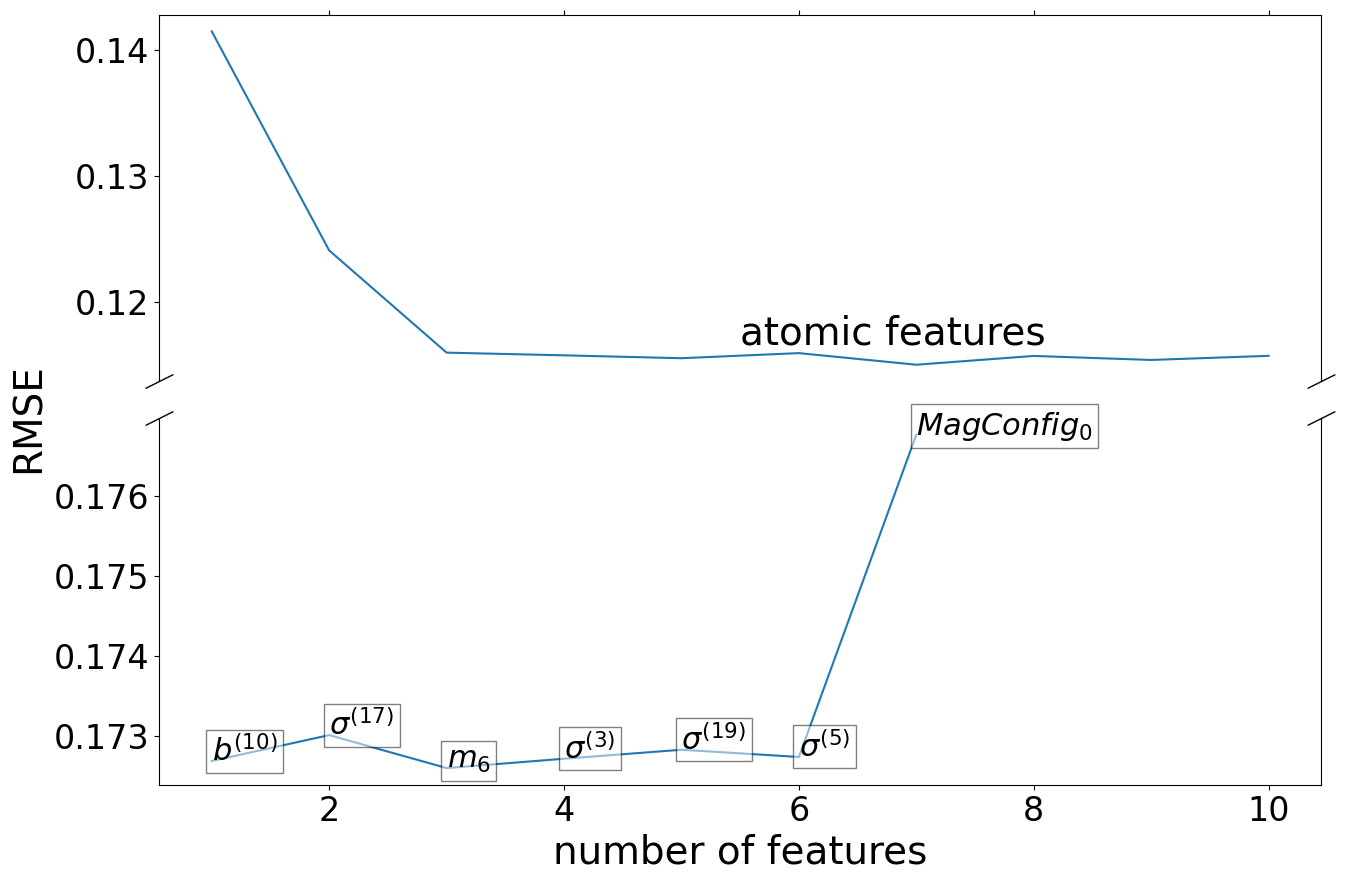

In [70]:
fig, ax = plt.subplots(2,1, sharex=True)
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'],ax = ax[1])
ax2 = plot_learning_curve(Bestscoresatomic['RandomForest_atomic'],Bestfeatsatomic['RandomForest_atomic'], ax = ax[0], dothelabels = False)
#ax = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax)
#ax = plot_learning_curve(Bestscores['RandomForest_bn'],Bestfeats['RandomForest_bn'], ax=ax)
#ax = plot_learning_curve(Bestscores['RandomForest_sigma'],Bestfeats['RandomForest_sigma'], ax=ax)
#ax = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax)
d = 0.015

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(1, d), (-1, -d)], markersize=20,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax[1].plot([0, 1], [1, 1], transform=ax1.transAxes, **kwargs)
ax[0].plot([0, 1], [0, 0], transform=ax2.transAxes, **kwargs)
ax[0].set_xlabel('')
ax[0].spines['bottom'].set_visible(False)
ax[0].xaxis.tick_top()
ax[1].spines['top'].set_visible(False)
ax[0].set_ylabel('')
ax[1].set_ylabel(ax[1].get_ylabel(), y=1)
ax[0].annotate('atomic features', xy=(0.5,0.1), xycoords = 'axes fraction', fontsize=28)
#ax.axhline(y=mses['random forest regressor']['EF']['test'])
#ax.axhline(y=mses['random forest regressor']['EF']['train'])
fig.subplots_adjust(hspace=0.1)
fig.savefig(get_plot_filename('atomic_vs_bop','brokenaxes'))

In [71]:
type(simple_model)

sklearn.pipeline.Pipeline

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA['EF'])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

In [ ]:
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate
param_grid = {}

FC['RandomForest_allset'] = FeatureConcatenate(
    pd.concat([DATA[real_feature], DATA['EF']], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target='EF',
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_allset'], Bestscores['RandomForest_allset'] = FC['RandomForest_allset'].build_features_list(
#    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=True,
    report_prefix='RandomForest_allset'+CASE
)

## incremental simple model

In [77]:
criterion

'test_score'

In [78]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    for max_index in range(1,len(columnsgroup)):
        incremental_model = RandomForestRegressor()
        feature_group = np.ravel(columnsgroup[:max_index])#  + list(columns_bn[:max_index])
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train['EF'])
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test['EF'], Ytest_predict, squared=False))
    return incremental_score

In [79]:
cols_an_bn = [ [an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [85]:
incremental_score_moments = incremental_learn(['MagConfig_0'] + columns_moments)
np.savetxt(get_table_filename('incremental_score','moments'),incremental_score_moments)

KeyError: "None of [Index(['MagConfig_0NSC_moments_0'], dtype='object')] are in the [columns]"

In [81]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(get_table_filename('incremental_score','an'),incremental_score_an)

In [82]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [83]:
from matplotlib.ticker import FormatStrFormatter

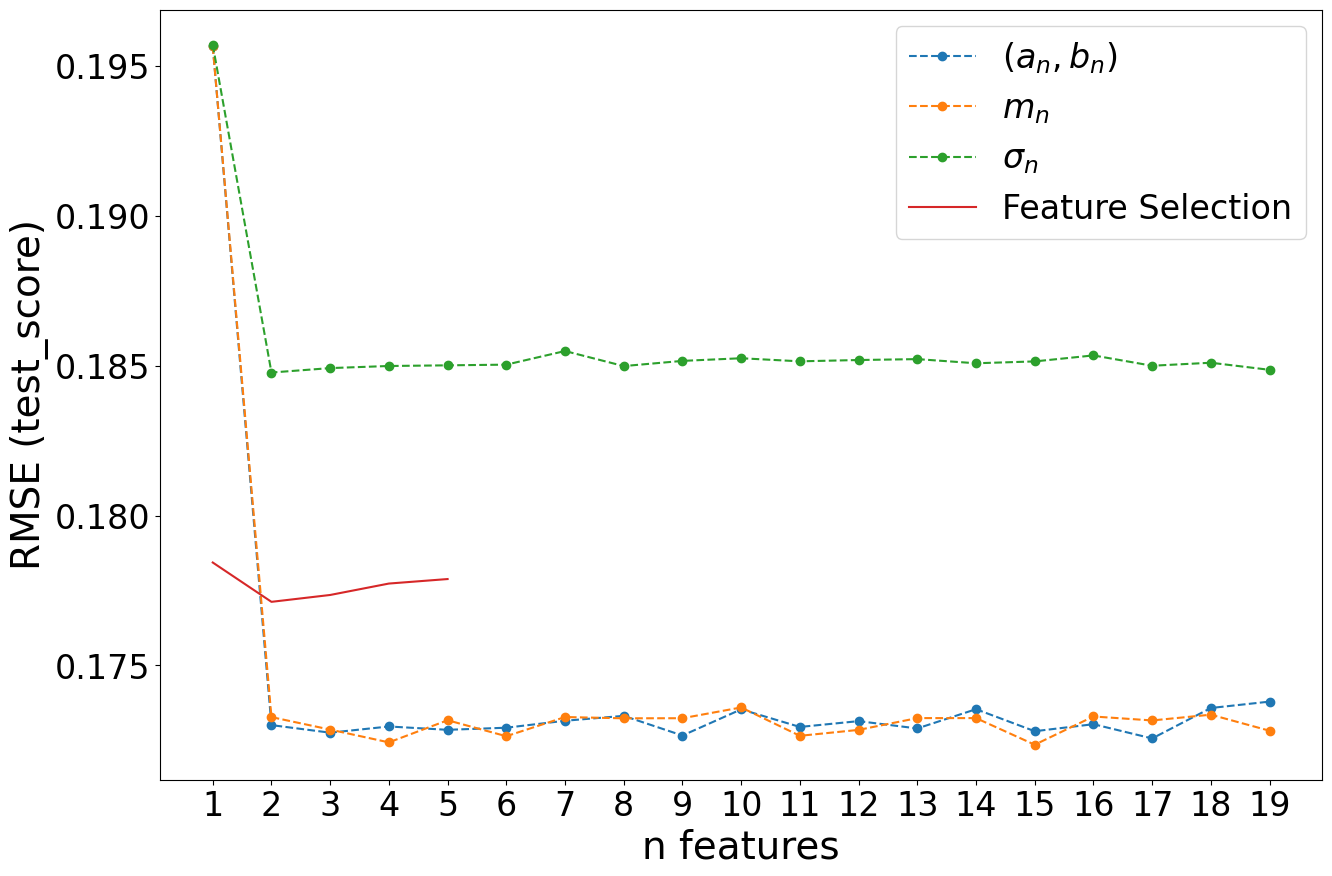

In [84]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])-1], Bestscores['RandomForest'][1:], label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(get_plot_filename('OrthogonalFeatures','1stoutscale_New'))

In [ ]:
# This is the standard way to import modules
del FeatureConcatenate
from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}

FC['GaussianProcess'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    GaussianProcessRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target='EF',
)

Bestfeats['GaussianProcess'], Bestscores['GaussianProcess'] = FC['GaussianProcess'].build_features_list(
    pass_force_refit=True,
    report_prefix='GP_'+CASE,
)

In [ ]:
Bestscores['GaussianProcess']

In [ ]:
plot_learning_curve(Bestscores['GaussianProcess'][2:],Bestfeats['GaussianProcess'][2:])

# Model Usage

In [83]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [84]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [85]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

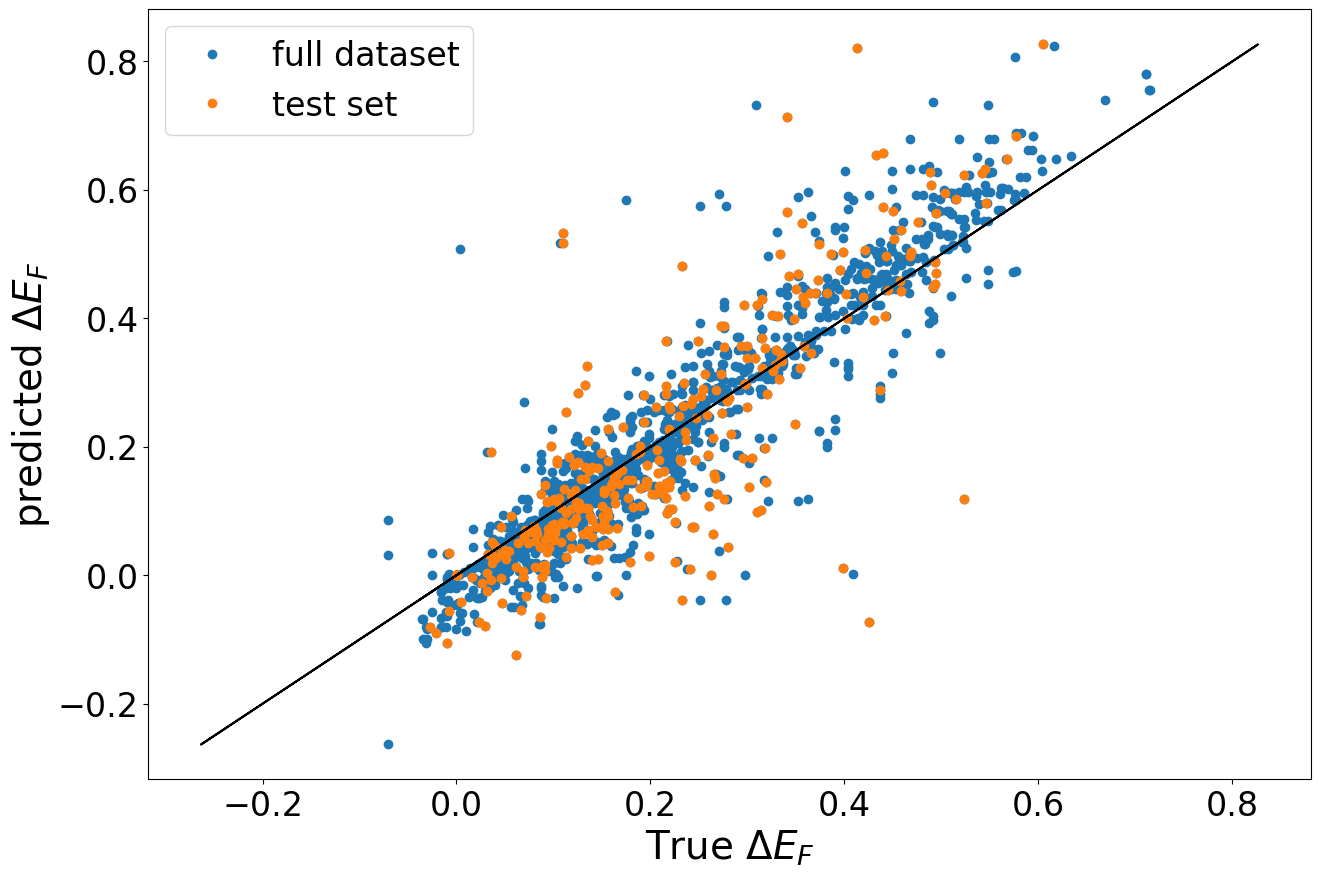

In [86]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')

In [87]:
hist_test = plt.hist(np.abs(E_test), bins=100, color='k', label='test set', density=True)
hist_train = plt.hist(np.abs(E_train), bins=50, label='train set', density=True)
plt.legend(); plt.ylabel('Counts'); 
plt.xlabel('$|E_F^{Predicted} - E_F ^{True}|$')

NameError: name 'E_test' is not defined

In [ ]:
mse_test['best scores']  = mean_squared_error(Y_test,best_Y_test_predict)
mse_train['best scores'] = mean_squared_error(Y_train,best_Y_train_predict)

In [ ]:
mse_train['gaussian process regressor']

In [ ]:
plt.bar(['test split','train split'],[mse_test['best scores'], mse_train['best scores']])
plt.bar(['test split','train split'], [mse_test['gaussian process regressor'], mse_train['gaussian process regressor']], alpha=0.5, width=0.5)
label = plt.ylabel('RMSE score')


## Prediction By Class

In [ ]:
EPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']],)

In [ ]:
import seaborn as sns

In [ ]:
#sns.lmplot(EPREDICT, DATA['EF'], hue=Target_Class)
ax = sns.scatterplot( EPREDICT, DATA['EF'], hue=Target_Class, sizes=np.abs(DATA['EF']-EPREDICT))
ax.set_ylabel('Target $E_f$'), ax.set_xlabel('Predicted $E_f$')
ax.plot(DATA['EF'], DATA['EF'], 'k', dashes=[10, 10,5])
plt.savefig('ColoredPrediction.pdf')

# Can I predict by phase?

In [ ]:
def incsplit(bestlist, alllist, phase='fcc', dotheplot=True):
    fitfull = []
    fitbest = []
    trainsplit = [0.1, 0.2, 0.3, 0.4,0.5, 0.6, 0.7, 0.8]
    progress = tqdm_notebook(trainsplit, ncols = 800, ascii = True)
    for splitsize in progress:
        dum, rmseful = PredictPhase(alllist, DATA, phase=phase,
                                  trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                  dotheplot=False)
        fitfull.append(rmseful)
        dum, rmsebest = PredictPhase(bestlist, DATA, phase=phase,
                                   trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                   dotheplot=False)
        fitbest.append(rmsebest)
    if dotheplot:
        fig, ax = plt.subplots()
        ax.plot(trainsplit, fitfull, '--o', label = 'full features')
        ax.plot(trainsplit, fitbest, '--o', label = 'only best features')
        ax.set_ylabel('RMSE on predictions for {:s}'.format(phase), fontsize=36)
        ax.set_xlabel('split fraction on target phase', fontsize=36)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=36)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=36)
        ax.legend()
        fig.savefig(f'graphs/incsplits_{phase}.pdf')
    return trainsplit, fitbest, fitfull

In [ ]:
def PredictPhase(
    features,
    _DATA,
    phase='C15',
    trainsplit = 0.2 ,
    _model=DecisionTreeRegressor(),
    _sample_weights = None,
    name=None,
    dotheplot = True,
    problemth = None
) :
    """this function train on the rest of the dataset + a protion of the target phase
    
    Paramaeters
    ===========
    features: list of features to use at training
    _DATA: dataset
    phase: target phase
    trainsplit: split of target phase to add on train set
    _model: regression model
    _sample_weights: sample weights
    dotheplot: weather to make the plot or not.
    plrblemth: threshold to get problematic phases
    
    Returns:
    trainsplit: fraction of target phase used at train (just for convenience.)
    r2scoretcp: r2score over test part of split.
    """
#    DATA = pd.concat((FEATURES, TARGET), axis=1)
    phase_index = _DATA.index.str.contains(phase)
    PXTRAIN, PXTEST, PYTRAIN, PYTEST = train_test_split(
        _DATA.loc[phase_index][features],
        _DATA.loc[phase_index]['EF'],
        train_size = trainsplit,
        shuffle = True,
        random_state=1234
    )
    XTRAIN = _DATA.drop(index=PYTEST.index)[features]#, columns=['EF'])
    YTRAIN = _DATA['EF'][XTRAIN.index]
    if _sample_weights is not None:
        TRAINW = _sample_weights.loc[XTRAIN.index]
        if isinstance(_model, sklearn.pipeline.Pipeline):
            fitparams = {_model.steps[-1][0]+'__'+'sample_weight': TRAINW}
        else:
            fitparams = {'sample_weight': TRAINW}
    else: 
        fitparams={}
    
    _model.fit(XTRAIN,YTRAIN, **fitparams)
    YPREDICT = _model.predict(XTRAIN)
    TCPPREDICT = _model.predict(PXTEST)
    TCPERRORS = TCPPREDICT - PYTEST
    ERRORS = YPREDICT - YTRAIN
    RMSE_full = mean_squared_error(YTRAIN, YPREDICT, squared=False)
    RMSE_tcp = mean_squared_error(PYTEST,TCPPREDICT, squared=False)
    rmsestring_full = 'RMSE score = {:.3f}'.format(RMSE_full)
    rmsestring_tcp = 'RMSE score = {:.3f}'.format(RMSE_tcp)
    if dotheplot:
        fig,ax = plt.subplots(1,2)
        ax[0].hist(np.abs(TCPERRORS), density=True, bins = 100, color='red', label='Predict on '+phase+' '+rmsestring_tcp)
        ax[0].hist(np.abs(ERRORS), density = True, bins = 100,alpha=.5, label = 'The rest of compounds '+rmsestring_full)
        ax[0].set_xlabel('$|E_f ^{train} - E_f ^{predict}|$  ')
        ax[0].set_ylabel('density count')
        ax[0].legend()

        ax[1].plot(YPREDICT,YTRAIN,'or',label='The rest of the systems')
        ax[1].plot(TCPPREDICT,PYTEST,'ok',alpha=0.5, label='prediction on '+phase)
        ax[1].set_xlabel('Train Values')
        ax[1].set_ylabel('Predicted Values')
        ax[1].plot(DATA['EF'],DATA['EF'],'g',label='data')
        ax[1].legend()
        if name == None:
            tit = fig.suptitle(type(_model))
        else:
            tit = fig.suptitle(name)
        fig.tight_layout()
    if problemth is not None:
        PROBLEMATIC = PYTEST[np.abs(TCPERRORS)>problemth]
        # I still need to get the position where to get a banner with the name of the problematic sample
        
    return trainsplit, RMSE_tcp
        

# split, r2 = PredictPhase(Bestfeats, DATA, phase='C15', trainsplit=0.5,  _sample_weights=Classes['Weights'], problemth=0.3)

In [ ]:
Interesting_classes = ['A15',  'C14', 'C36',  'mu', 'sigma']

list_BOP  = []
for p, phase in enumerate(Interesting_classes):
    print (phase)
    list_BOP.append(
        PredictPhase(np.array(real_feature)[:10], DATA, phase=phase) #_sample_weights=Classes['Weights'])
    )
#        list_BOP.append( test(features_with_importances_weights[:10]['features'], DATA, phase=phase, _sample_weights=Classes['Weights'], name='Random Forest Regressor Weighted') )
%store list_BOP

In [ ]:
def incsplit(bestlist, alllist, phase='fcc', dotheplot=True):
    fitfull = []
    fitbest = []
    trainsplit = [0.3, 0.4,0.5, 0.6]
    progress = tqdm_notebook(trainsplit, ncols = 800, ascii = True)
    for splitsize in progress:
        dum, rmseful = PredictPhase(alllist, DATA, phase=phase, 
                                  trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                  dotheplot=False)
        fitfull.append(rmseful)
        dum, rmsebest = PredictPhase(bestlist, DATA, phase=phase,
                                   trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                   dotheplot=False)
        fitbest.append(rmsebest)
    if dotheplot:
        fig, ax = plt.subplots()
        ax.plot(trainsplit, fitfull, '--o', label = 'full features')
        ax.plot(trainsplit, fitbest, '--o', label = 'only best features')
        ax.set_ylabel('RMSE on predictions for {:s}'.format(phase), fontsize=36)
        ax.set_xlabel('split fraction on target phase', fontsize=36)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=36)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=36)
        ax.legend()
        fig.savefig(f'graphs/incsplits_{phase}.pdf')
    return trainsplit, fitbest, fitfull

In [ ]:
performances  = {}
Interesting_classes = ['A15',  'C14', 'C36', 'chi',  'sigma']

In [ ]:
for p, phase in enumerate(Interesting_classes):
    if phase not in performances:
        splits, scoresbest, scorefull = incsplit(np.array(Bestscores['RandomForest']),Bestfeats['RandomForest'],phase=phase)
        performances[phase] = {'splits': splits, 'scoresbest': scoresbest, 'scoresfull':scorefull }
    else:
        fig, ax = plt.subplots()
        ax.plot(performances[phase]['splits'], performances[phase]['scoresfull'], '--o', label = 'full features')
        ax.plot(performances[phase]['splits'], performances[phase]['scoresbest'], '--o', label = 'only best features')
        ax.set_ylabel('$RMSE$ on predictions for {:s}'.format(phase))
        ax.set_xlabel('split fraction on target phase')
        fig.show()
#        ax.set_yticklabels(ax.get_yticklabels(), fontsize=3)
#        ax.set_xticklabels(ax.get_xticklabels(), fontsize=36)
        ax.legend()
        fig.savefig(f'graphs/incsplits_{phase}.pdf')

In [ ]:
for phase in performances.keys():
    plt.plot(performances[phase]['splits'], performances[phase]['scoresfull'], label=phase)
plt.legend()
plt.xlabel('test split size', labelpad = 20)
plt.ylabel('RMSE (eV)',labelpad = 20)
plt.savefig('graphs/CrCoWResultIncSplit.pdf')

## Errors

In [ ]:
DATA['EF'] != 0

In [ ]:
# /DATA['EF'])[DATA['EF']!=0]

In [ ]:
ERRORS = (YPREDICT - DATA['EF'] )

# Further topics and keywords:

1. Overfitting and cross validation

2. Other regression models:
    - Support Vector machines
    - Multi perceptron regressors (easy neural networks)
    
    
3. Outliers detection ( failed to implement so far)
    - SVM based methods
    - Covariance based methods
      
    
4. Error measurement: 
    - root mean squared error

5. Goodnes of model and fine tuning: 
    - ROC curves

6. Classification methods

7. Bayesian theory of probability

8. Books
    - Bishop,  'Pattern Recognition and Machine Learning'
    - Géron, 'Hands on machine learning with scikit-learn, Keras & Tensor Flow'


# Other Properties

In [ ]:
AtomicDATA = [
    'electronegativity_min', 'electronegativity_max', 'atomicRadius_avg',
    'atomicRadius_min', 'atomicRadius_max','ionizationEnergy_avg', 'ionizationEnergy_min',
    'ionizationEnergy_max', 'density_avg', 'density_min', 
    'density_max', 'Nd_avg', 'Nd_min', 'Nd_max', 'period_number_avg',
    'period_number_min', 'period_number_max',
]

In [ ]:
for col in AtomicDATA:
    Original[col] = Original[col].apply(lambda v: v[0])#.apply(lambda v: v[0])

In [ ]:
Original[AtomicDATA].dropna()

In [ ]:
AtomicFeatures = Original[AtomicDATA+['E_f']]

In [ ]:
Atomic_feature_titles = []
for i, atomic in enumerate(AtomicFeatures):
    Atomic_feature_titles.append(
        re.sub('_(\w+)','_\{\\1\}', atomic)
    )
    Atomic_feature_titles[-1] ='$'+Atomic_feature_titles[-1]+'$'
    

In [ ]:
Atomic_feature_titles = pd.Series(Atomic_feature_titles, index=AtomicFeatures.columns)

## Class Weights

```python
Target_Class_Original = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class_Original[Target_Class_Original.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class_Original[Target_Class_Original.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class_Original[Target_Class_Original.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class_Original[Features.Struc == 'hcp'] = 'hcp'
Target_Class_Original[Features.Struc == 'bcc'] = 'bcc'
Target_Class_Original[Features.Struc == 'fcc'] = 'fcc'
Target_Class_Original[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class_Original[Features.Struc.str.contains('SQS-L12')] = 'fcc'

Target_Class_Original[    
    Target_Class_Original.str.contains('Al42W') |\
    Target_Class_Original.str.contains('Al9Co2') |\
    Target_Class_Original.str.contains('Al5W') |\
    Target_Class_Original.str.contains('Al12W') |\
    Target_Class_Original.str.contains('Al4W') |\
    Target_Class_Original.str.contains('Al5Co2')
] = 'others'


ClassesOriginal = pd.DataFrame(Target_Class_Original.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class_Original.value_counts()
ClassesOriginal['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()
```

## The Machine Learning

## Atomic Features

In [ ]:
del FeatureConcatenate

# This is the standard way to import modules
from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
# this way allows to dynamically load the module while it is being developed.
FeatureConcatenate = SourceFileLoader(
    'FC',
    'BopFoxFeaturizer/FeatureConcatenate.py'
).load_module().FeatureConcatenate

FC2 = FeatureConcatenate(
    Original[Atomic_feature_titles.index.values],
    RandomForestRegressor(),
    param_grid,
    AtomicDATA,
    data_target='E_f',
#    sample_weights = ClassesOriginal['Weights']
)

Atomfeats, atomscores = FC2.build_features_list(
#    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=True,
    report_prefix='atom_demonstration_',
)

## Structure Features from Library

In [ ]:
MatminerStructureFeatures = pd.read_pickle('Structure_matminer.pkl')

In [ ]:
MatminerFeatures = MatminerStructureFeatures.columns.drop('EF')

In [ ]:
matminer_feature_titles = []
for i, feat in enumerate( MatminerFeatures):
    matminer_feature_titles.append(
        feat.split(' ')[-1]
    )

In [ ]:
del FeatureConcatenate

# This is the standard way to import modules
from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
# this way allows to dynamically load the module while it is being developed.
FeatureConcatenate = SourceFileLoader(
    'FC',
    'BopFoxFeaturizer/FeatureConcatenate.py'
).load_module().FeatureConcatenate
param_grid={}
FC2 = FeatureConcatenate(
    MatminerStructureFeatures,
    RandomForestRegressor(),
    param_grid,
    MatminerFeatures,
    data_target='EF',
#    sample_weights = ClassesOriginal['Weights']
)

MMfeats, MMscores = FC2.build_features_list(
#    best_feature_proposal=['NSC_bn_1'],
    pass_force_refit=True,
    report_prefix='Matminer_demonstration_',
)

In [ ]:
MMscores

In [ ]:
bestscores

In [ ]:
plt.plot(np.arange(1,len(bestscores)+1),bestscores) 
plt.ylabel ("RMSE")
plt.xlabel ("number of features")
for i, feat in enumerate(Bestfeats):
    t = plt.annotate(
        feature_titles[feat],
        ((i+1), bestscores[i]),
        ((i+1), bestscores[i]),
        fontsize=22
    )
    t.set_bbox(dict(facecolor='white', alpha=0.5))
    
plt.plot(np.arange(1, len(atomscores)+1),atomscores)
plt.annotate('atomic only features', (5, atomscores[-1]+0.01) , fontsize=20)
plt.annotate('BOP features', (5, bestscores[5]+0.01) , fontsize=20)
plt.savefig('graph/atomic_vs_bop.features_RFR.pdf')


In [ ]:
CORRS['NSC_SIGMA_9'][CORRS['NSC_SIGMA_9'].abs()>0.5]

In [ ]:
Bestfeats

In [ ]:
ax = sns.scatterplot(DATA['NSC_SIGMA_0'],DATA['NSC_SIGMA_4'],cmap='winter',hue=DATA['EF'])
sns.scatterplot(DATA['NSC_SIGMA_9'],DATA['NSC_SIGMA_10'],hue=DATA['EF'])

In [ ]:
CORRS['NSC_SIGMA_9'][CORRS['NSC_SIGMA_9']>0.5]